Аналитическая задача — построить модель для прогнозирования стоимости квартиры.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Шаг 1. Загрузка данных и чтение данных из файлов

In [2]:
df = pd.read_csv("home_price.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   last_price           23699 non-null  float64
 1   total_area           23699 non-null  float64
 2   rooms                23699 non-null  int64  
 3   ceiling_height       14504 non-null  float64
 4   floors_total         23613 non-null  float64
 5   living_area          21796 non-null  float64
 6   floor                23699 non-null  int64  
 7   is_apartment         2775 non-null   object 
 8   studio               23699 non-null  bool   
 9   open_plan            23699 non-null  bool   
 10  kitchen_area         21421 non-null  float64
 11  balcony              12180 non-null  float64
 12  airports_nearest     18157 non-null  float64
 13  cityCenters_nearest  18180 non-null  float64
 14  parks_around3000     18181 non-null  float64
 15  parks_nearest        8079 non-null  

In [4]:
df.columns

Index(['last_price', 'total_area', 'rooms', 'ceiling_height', 'floors_total',
       'living_area', 'floor', 'is_apartment', 'studio', 'open_plan',
       'kitchen_area', 'balcony', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest'],
      dtype='object')

In [5]:
df

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
0,13000000.0,108.00,3,2.70,16.0,51.0,8,NaN,False,False,25.00,NaN,18863.0,16028.0,1.0,482.0,2.0,755.0
1,3350000.0,40.40,1,NaN,11.0,18.6,1,NaN,False,False,11.00,2.0,12817.0,18603.0,0.0,NaN,0.0,NaN
2,5196000.0,56.00,2,NaN,5.0,34.3,4,NaN,False,False,8.30,0.0,21741.0,13933.0,1.0,90.0,2.0,574.0
3,64900000.0,159.00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,28098.0,6800.0,2.0,84.0,3.0,234.0
4,10000000.0,100.00,2,3.03,14.0,32.0,13,NaN,False,False,41.00,NaN,31856.0,8098.0,2.0,112.0,1.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9700000.0,133.81,3,3.70,5.0,73.3,3,NaN,False,False,13.83,NaN,24665.0,4232.0,1.0,796.0,3.0,381.0
23695,3100000.0,59.00,3,NaN,5.0,38.0,4,NaN,False,False,8.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23696,2500000.0,56.70,2,NaN,3.0,29.7,1,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,11475000.0,76.75,2,3.00,17.0,NaN,12,NaN,False,False,23.30,2.0,39140.0,10364.0,2.0,173.0,3.0,196.0


Шаг 2. Первичная обработка данных (при необходимости):
- скорректировать заголовки;
- скорректировать типы признаков;
- проверить наличие дублирующихся записей;
- проверить наличие аномальных значений;
- восстановить пропущенные значения.


In [7]:
def delete_nan(dataframe):
    cleaned_dataframe = dataframe.dropna()  
    return cleaned_dataframe

if __name__ == "__main__":
    df = pd.read_csv("home_price.csv")
    df_clean = delete_nan(df)


Шаг 3. Выполнен разведочный анализ данных EDA

In [8]:
df_clean.describe()

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
count,2.680000e+02,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,8.225887e+06,71.053806,2.328358,3.209515,9.335821,41.078321,5.291045,11.655672,1.138060,27552.764925,12301.623134,1.466418,495.951493,1.716418,477.604478
std,6.908651e+06,38.284598,1.072476,5.944358,5.524808,24.424278,4.239682,6.192262,1.180192,11758.825192,9065.748927,0.715525,390.920820,0.853387,280.475840
min,2.300000e+06,25.000000,1.000000,2.300000,2.000000,13.800000,1.000000,5.000000,0.000000,8426.000000,208.000000,1.000000,17.000000,1.000000,16.000000
25%,4.500000e+06,45.375000,1.750000,2.600000,5.000000,24.550000,2.000000,7.800000,0.000000,19606.000000,6191.750000,1.000000,288.750000,1.000000,243.750000
50%,6.070000e+06,60.500000,2.000000,2.750000,9.000000,36.250000,4.000000,10.000000,1.000000,25815.000000,11745.500000,1.000000,433.500000,1.000000,464.500000
75%,9.292500e+06,82.475000,3.000000,3.000000,12.000000,49.700000,7.000000,13.000000,2.000000,35000.000000,14604.250000,2.000000,577.000000,3.000000,713.500000
max,6.650000e+07,312.000000,6.000000,100.000000,25.000000,154.000000,22.000000,45.000000,5.000000,69410.000000,52768.000000,3.000000,2532.000000,3.000000,1199.000000


In [9]:
missing = df_clean.isnull().sum()
print("\nКоличество пропущенных значений в каждом столбце:" , len(missing[missing > 0]))




Количество пропущенных значений в каждом столбце: 0


In [10]:
duplicate_rows = df_clean[df_clean.duplicated(keep=False)]
print("\nКоличество дублирующих строк:", len(duplicate_rows))


Количество дублирующих строк: 0


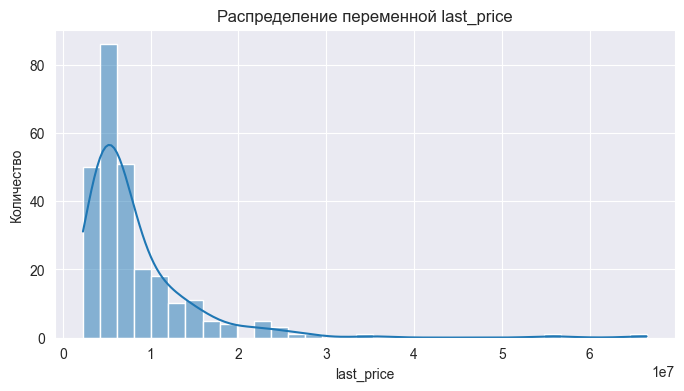

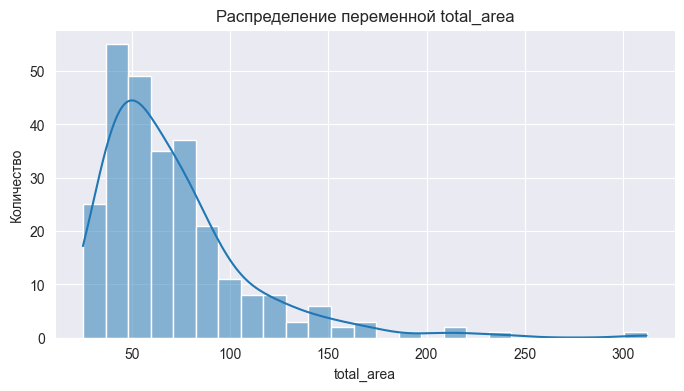

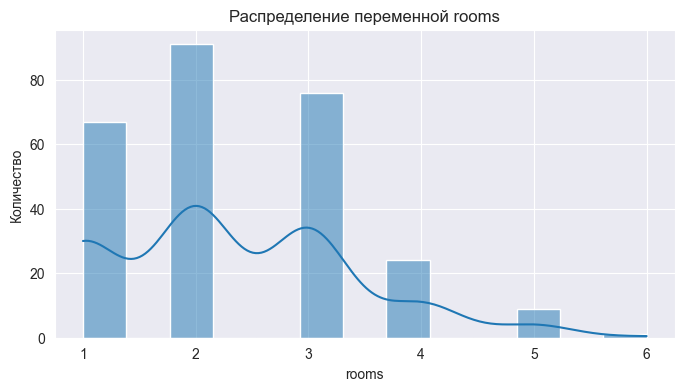

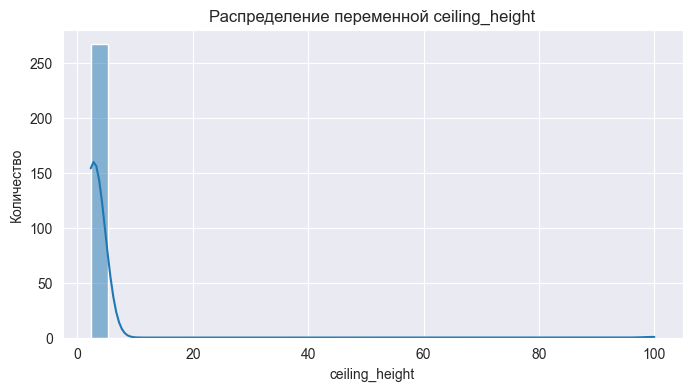

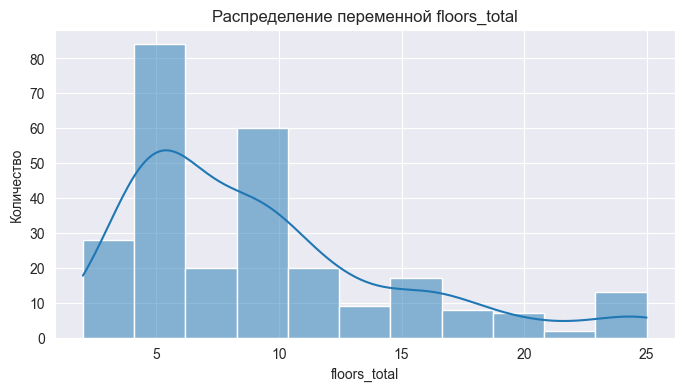

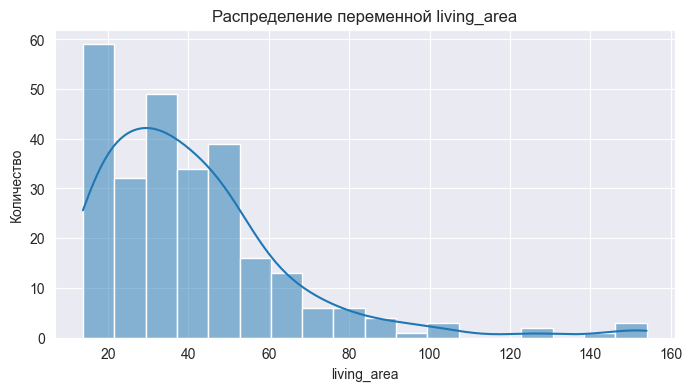

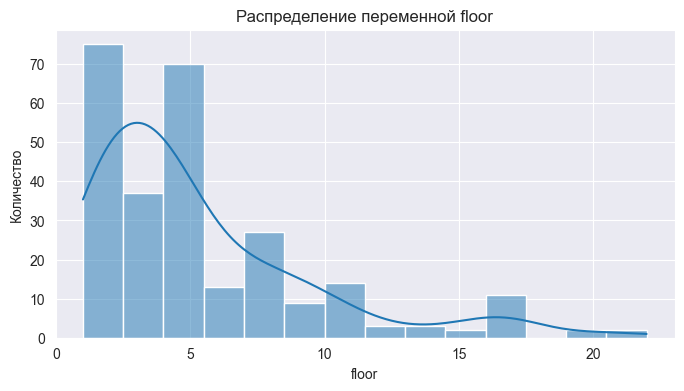

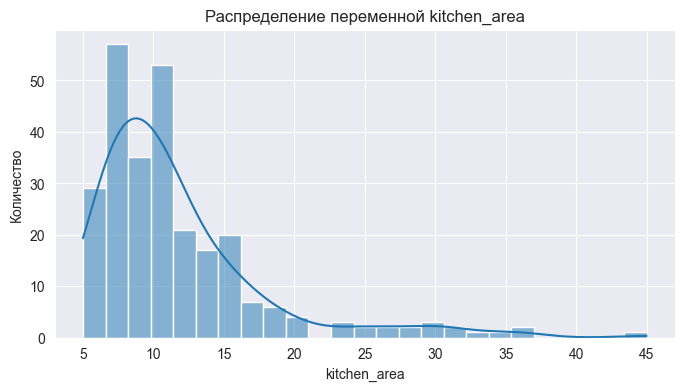

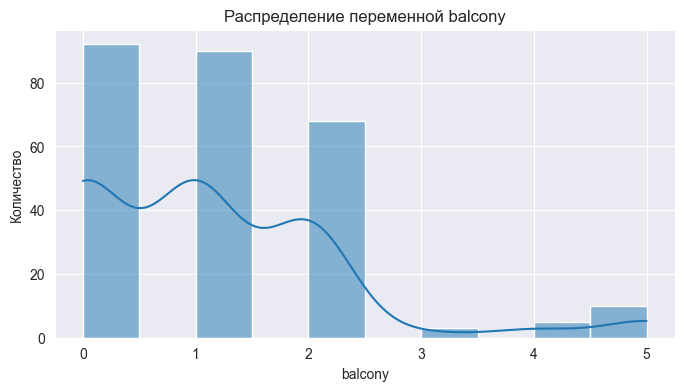

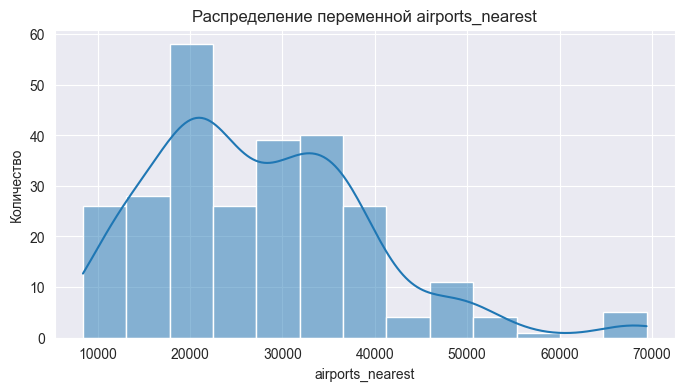

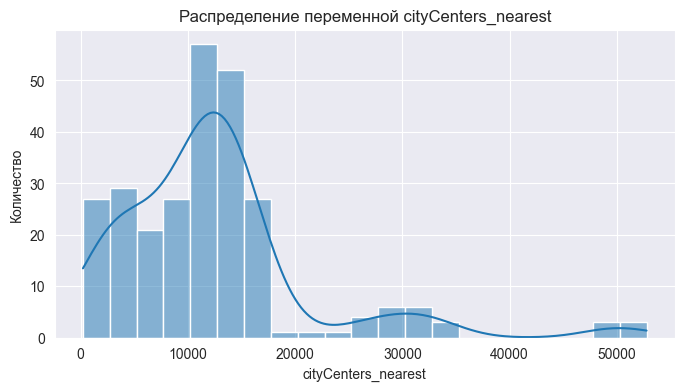

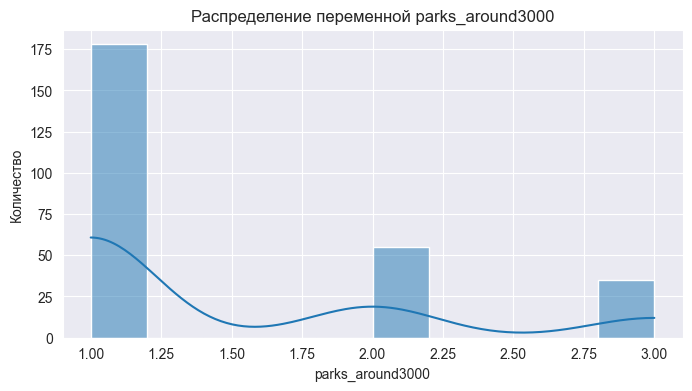

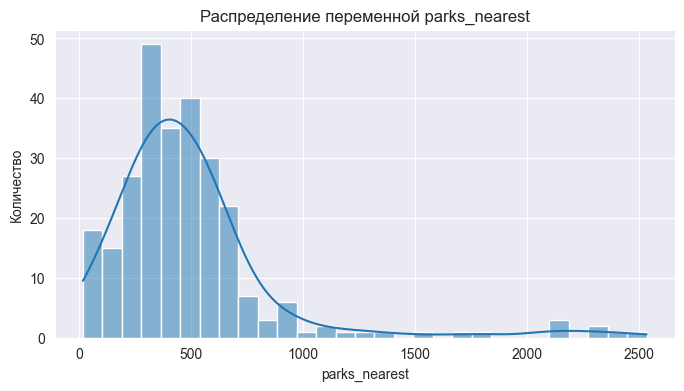

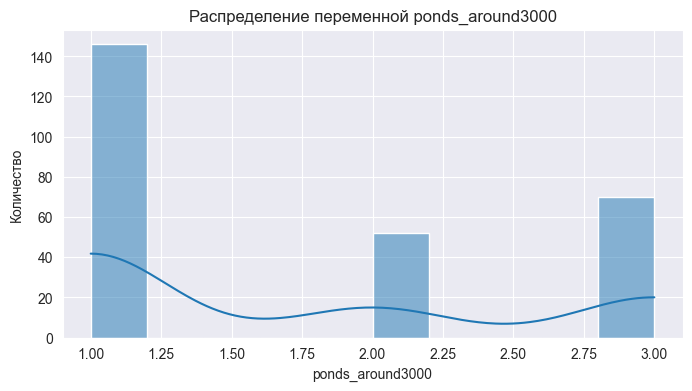

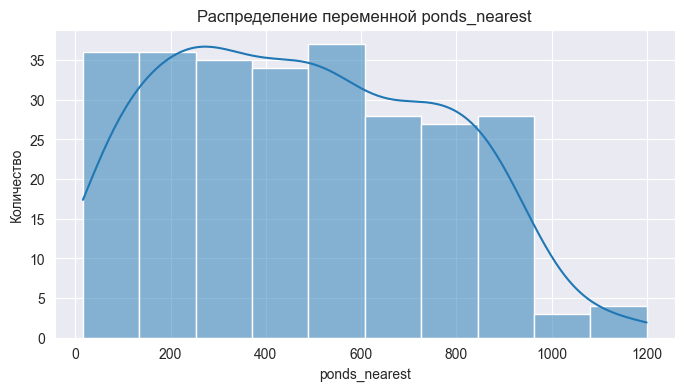

In [11]:
df_columns = df_clean.select_dtypes(include=['float64', 'int64']).columns
for column in df_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean[column], kde=True) 
    plt.title(f'Распределение переменной {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.show()

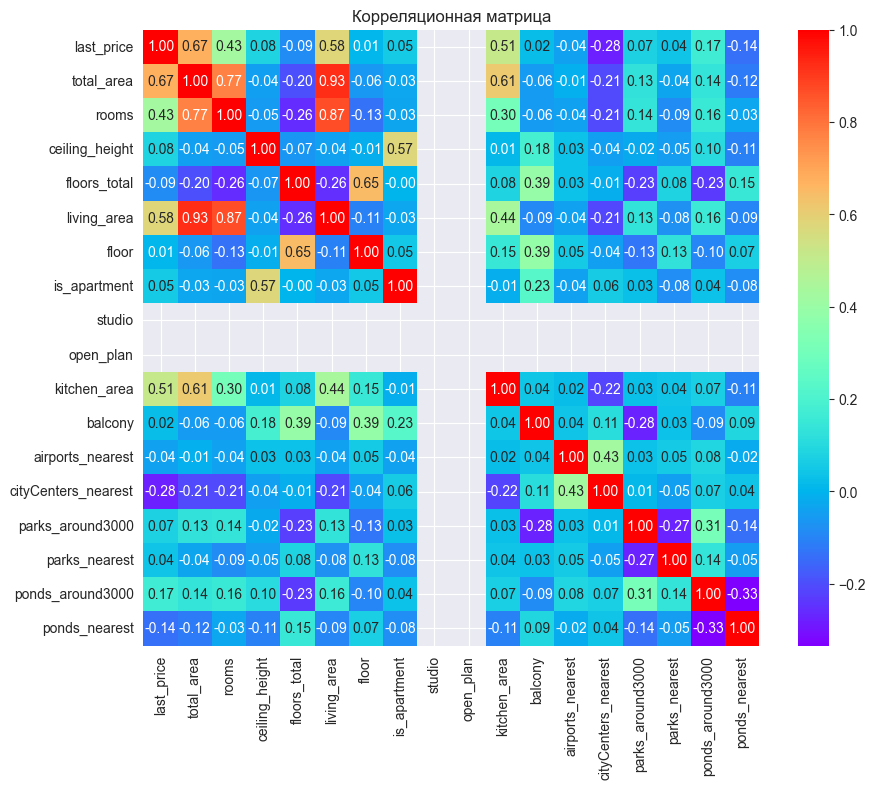

In [12]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='rainbow', square=True)
plt.title('Корреляционная матрица')
plt.show()

Шаг 4. Провести исследовательский анализ данных:
- определены важные признаки;
- выполнен поиск взаимосвязей между признаками;
- выполнено уменьшение размерности массива данных;
- составлена гипотеза о данных и выполнена проверка соответствующей гипотезы.


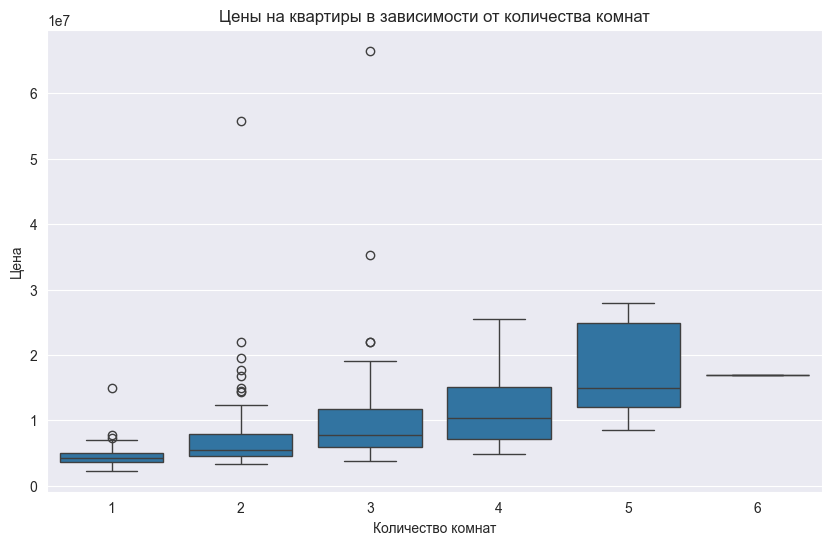

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='rooms', y='last_price', data=df_clean)
plt.title('Цены на квартиры в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена')
plt.show()

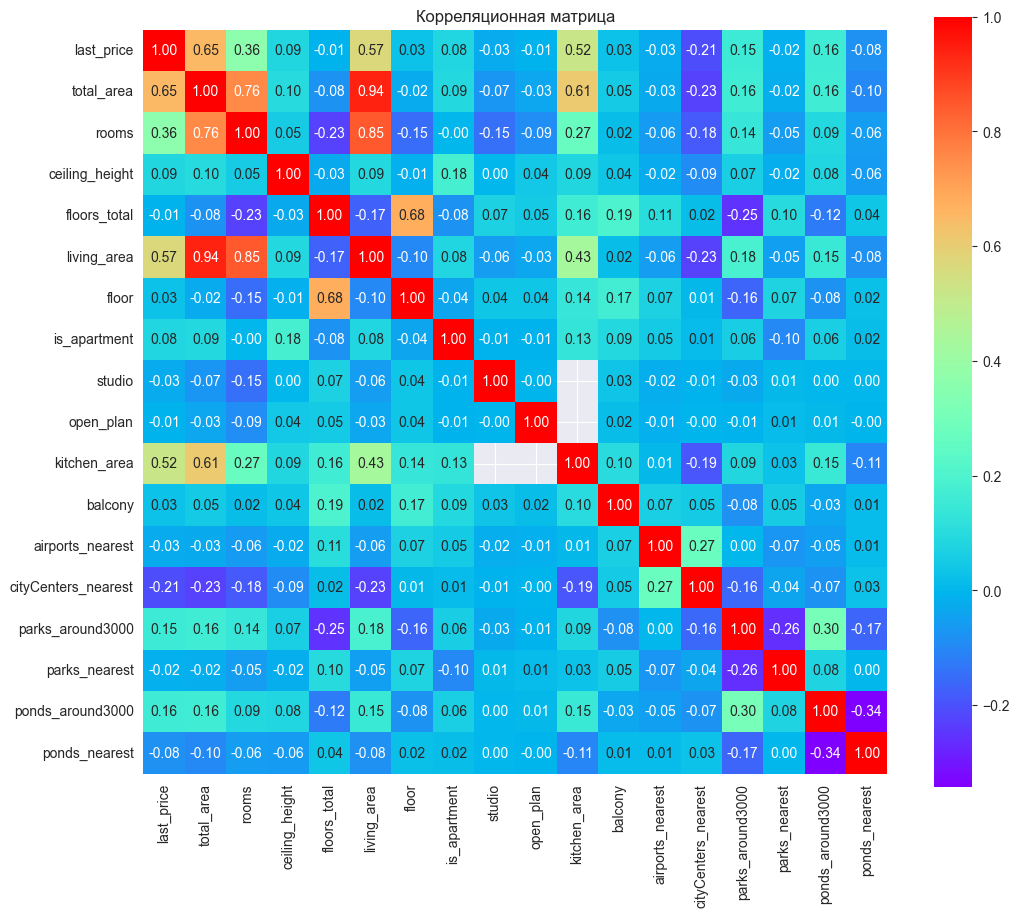

In [14]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='rainbow', square=True)
plt.title('Корреляционная матрица')
plt.show()


Учитывая, что в огромной выборке мы получили достаточно грязные данные, путём удаления неизвестных нам значений, мы получили выборку всего с 268 строками. Переименовывать существующие столбцы сочли лишним, хотя при желании заказчика - можем переименовать.
- Выбросов практически не обнаружено - за исключением того, что есть достаточно большие квартиры по площади. Более 300 квадратных метров, и это значительно влияет на цену. Соответственно среднее будет не совсем уместно (больше покажем в презентации), но медиана вполне себе складывается.
- Также большой процент выборки был именно грязным в столбце "апартаменты", но мы не сочли неизвестную информацию принимать на веру - и ставить на свой страх и риск 0 вместо nan - так как в этом случае объективность исследования могла быть под угрозой.
- Заметили также что чистые данные остались больше с домов до 5 этажами, хотя присутствуют и более высокие дома, до 25 этажей. 
- Не нашли информацию о годе постройки - нам кажется, это было бы тоже важным фактором на влияние цены, ведь зачастую новострой стоит дороже
- Также нет информации о качестве ремонта в данной выборке, что тоже бы повлияло на стоимость так или иначе
- Замечена странная аномалия касаемо балконов - значение может доходить до 5(может всё-таки это метраж?), но и конечно не удивительно что есть квартиры без балконов-
- так как многие дома строятся именно без них, особенно в центре - экономия квадратных метров
- По поводу кухонь - почему-то они в основном небольшие 5-10 метров, и это видимо потому что попали в выборку 2-5 этажные дома в своём большом количестве
- В основном в нашей выборке 2-3 комнатные квартиры, но есть также и 4-комнатные, а также 5 и 6. Однокомнатных же меньше чем двушек и трёшек
-  Самые дорогие квартиры - 66.5 и 55.8 миллионов рублей, также есть ещё небольшой выброс - квартира стоимостью 35.8 тысяч рублей
- Самая дешёвая квартира 2.3 миллиона рублей. 
- Из-за того, что у нас разная стоимость квартир - среднее получаем чуть больше 8 миллионов
- Но если смотреть квартилям - тут ситуация иная: 25й - 4.5, 50й - 6 миллионов с небольшим, 75й - примерно 9.3, и выбросы на 95м персентиле - там 19.42 миллиона
- Поэтому решили в дальнейшем привести также раскладку по каждой категории квартир - а именно в зависимости от количества комнат сделать анализ отдельно однушек, двушек, трёшек, и 4-5-6-комнатных - то есть четыре разных группы
- Если смотреть на картину в целом, то видим, что очевидно что факторы влияющие на цену это предсказуемо: общая площадь и жилая площадь - далее, судя, по корелляционной матрице - это параметры кухни - чем больше, тем дороже - ну и в больших квартирах и кухня больше, как следствие, также немаловажно количество комнат - но видимо не всегда, так как показатель 0.36 - нам говорит, что не всегда количество комнат влияет на цену, а значит есть в нашей выборке квартиры, которые несмотря на то, что имеют меньше комнат, имеют жилплощадь и общую площадь больше, скажем те же большие балконы или кухни, так как отношение количества комнат к общей площади квартир в два и боле раз ниже.
- Кроме этого, существенно на цену влияет количество водоёмов и парков в радиусе 3 км - в сумме эти два фактора почти так же важны - 0.31, как и количество комнат, но мы конечно понимаем что не всегда, где парки там и озёра, и их количество непропорционально друг другу, и не всегда расположение квартир к паркам и водоёмам будет одинаковой, а также нельзя напрямую провести корелляцию что влияют оба фактора сразу, но можно предположить что влияют как оба фактора сразу, так и каждый по отдельности.
- Приведённые минусы в корреляционной матрице мы поняли, что являются больше плюсами - так немаловажным фактором влияющим на цену квартиры, является расстояние к центру города - здесь мы видим показатель примерно 0.21 - конечно, все хотят жить ближе к центру, и это повышает цену значительно, несмотря, что может быть меньше комнат и дальше водоём и парк - цены квартир ближе к центру - выше.
- Далее, в сумме как число водоёмов в радиусе 3 км, у нас два фактора - апартаменты и расстояние до ближайшего водоёма - по 0.8 значимости на радуге матрицы. Апартаменты в общем предполагают большего количества комнат, мы это видим на матрице.
- Всего 2 квартиры апартаментов и одна квартира открытого плана, что достаточно мало даёт нам для построения гипотезы относительно этих факторов. Также в нашей выборке только одна студия, что тоже странно - так как студии сейчас очень распространённый тип планировки
- Отсюда пришли к выводу, что будем выводить ещё одну выборку, где студия, апартаменты и открытый план столбцы мы просто исключим, чтобы на большей выборке посмотреть как изменится корреляция открытых и найденных нами факторов

In [15]:
requided_cols = ["last_price", "total_area", "living_area", "rooms", "floor", "floors_total", "kitchen_area", "ceiling_height", "balcony", "cityCenters_nearest", "parks_around3000", "parks_nearest", "ponds_around3000", "ponds_nearest", "airports_nearest"]
df_big = df[requided_cols]

In [16]:
df_big.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   last_price           23699 non-null  float64
 1   total_area           23699 non-null  float64
 2   living_area          21796 non-null  float64
 3   rooms                23699 non-null  int64  
 4   floor                23699 non-null  int64  
 5   floors_total         23613 non-null  float64
 6   kitchen_area         21421 non-null  float64
 7   ceiling_height       14504 non-null  float64
 8   balcony              12180 non-null  float64
 9   cityCenters_nearest  18180 non-null  float64
 10  parks_around3000     18181 non-null  float64
 11  parks_nearest        8079 non-null   float64
 12  ponds_around3000     18181 non-null  float64
 13  ponds_nearest        9110 non-null   float64
 14  airports_nearest     18157 non-null  float64
dtypes: float64(13), int64(2)
memory usag

In [17]:
def delete_nan(dataframe):
    cleaned_dataframe = dataframe.dropna()  
    return cleaned_dataframe

if __name__ == "__main__":
    df = df_big
    df_big_clean = delete_nan(df)

- Видим, что в таком случае выборка у нас не 269 значений, а уже 1349
- Решили также переименовать все наши столбцы, для более понятного вывода на русском

In [24]:
df_big_ru = df_big_clean.rename(columns={
    "last_price": "Цена", 
    "total_area": "Общая площадь", 
    "living_area": "Жилая площадь", 
    "rooms": "Количество комнат",
    "floor": "Этаж",
    "floors_total": "Этажей в доме",
    "kitchen_area": "Пл. кухни",
    "ceiling_height": "Выс. потолка",
    "balcony": "Балкон",
    "cityCenters_nearest": "Расст. к центру города",
    "parks_around3000": "Парки, 3 км",
    "parks_nearest": "Расст. до парка",
    "ponds_around3000": "Озёра, 3 км",
    "ponds_nearest": "Расст. до озера",
    "airports_nearest": "Расст. до аэропорта"
} )

In [25]:
missing = df_big_ru.isnull().sum()
print("\nКоличество пропущенных значений в каждом столбце:" , len(missing[missing > 0]))


Количество пропущенных значений в каждом столбце: 0


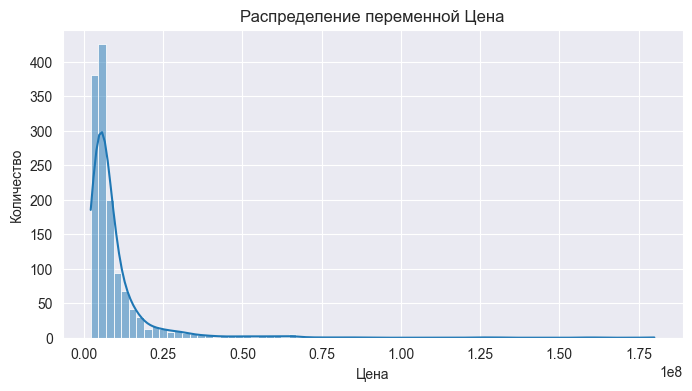

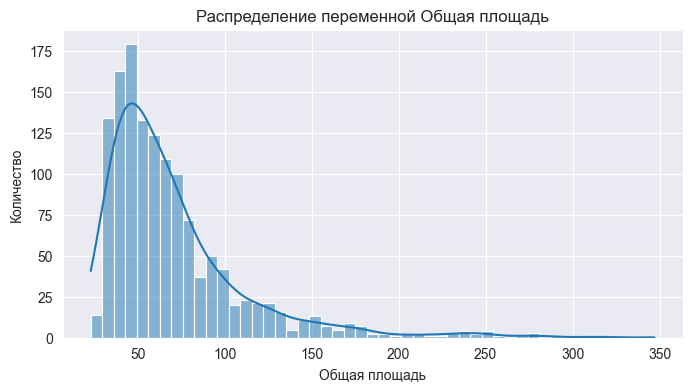

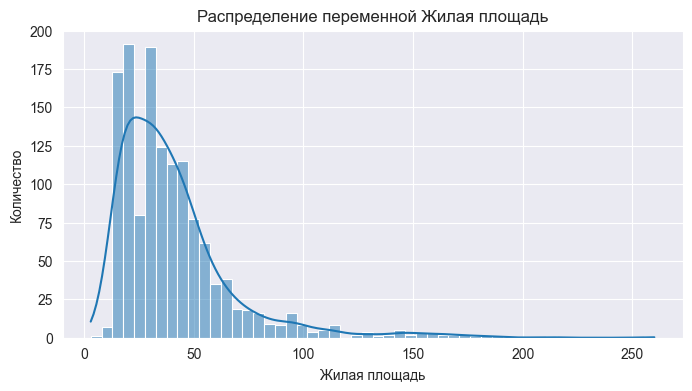

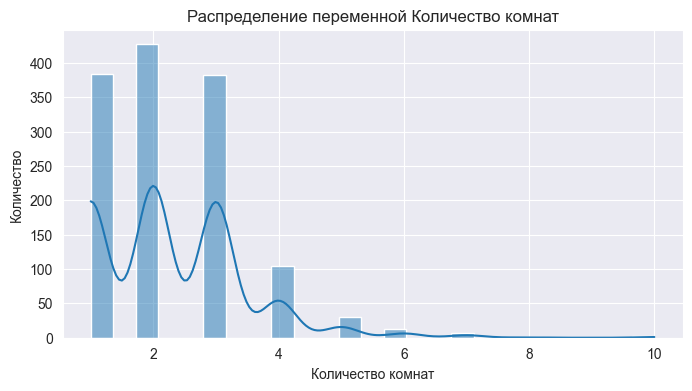

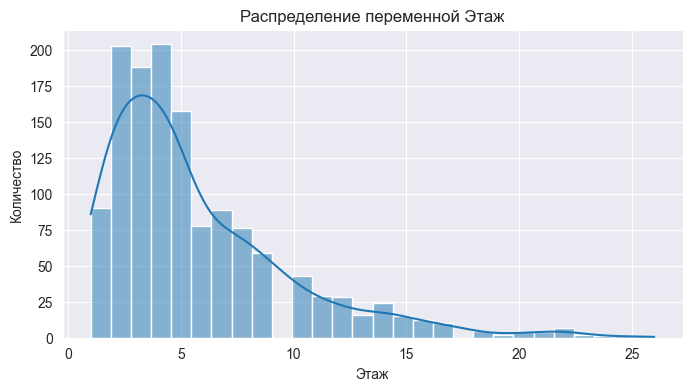

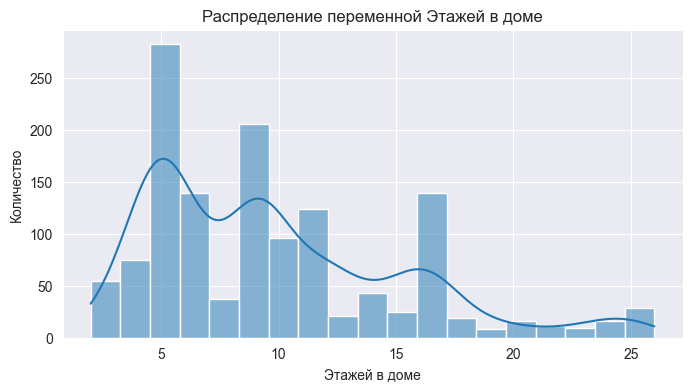

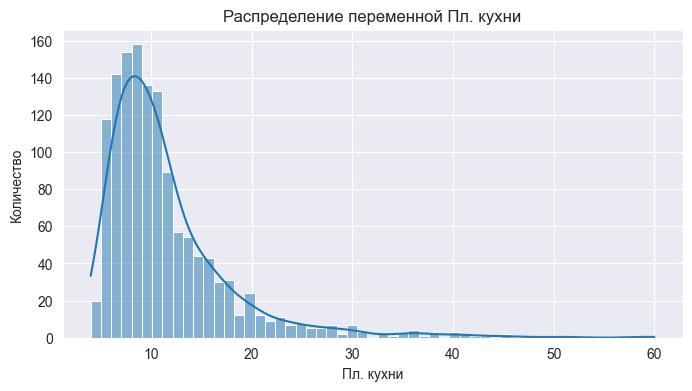

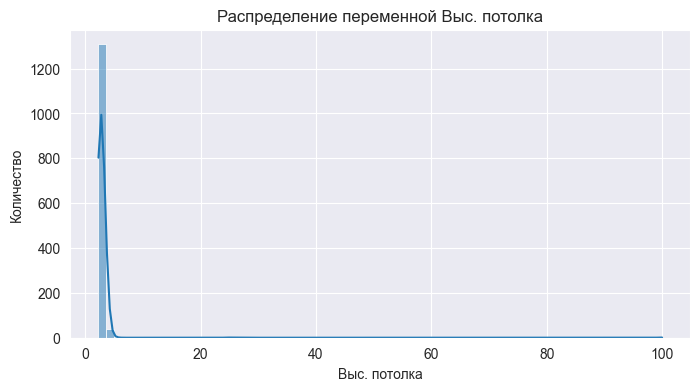

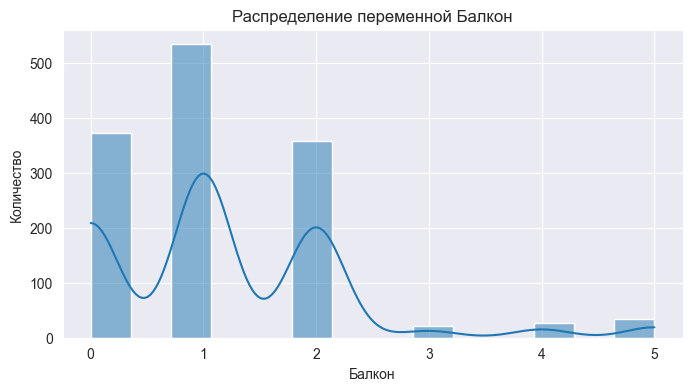

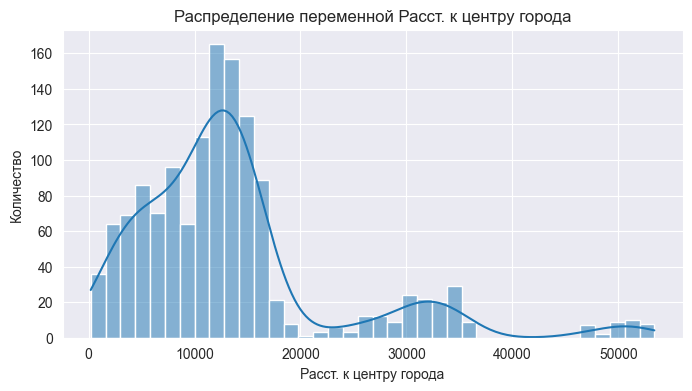

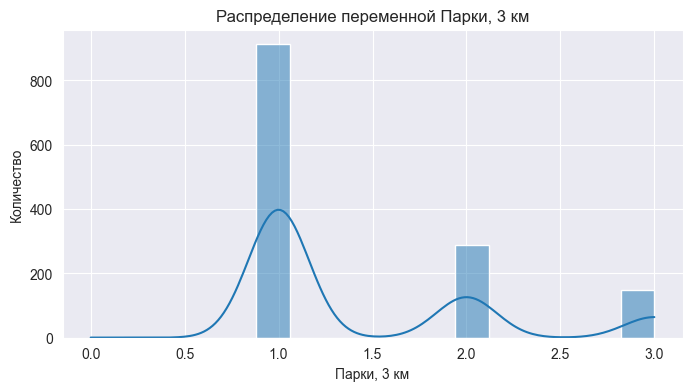

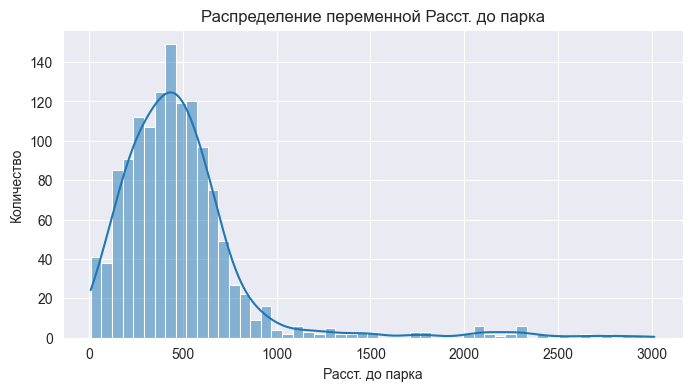

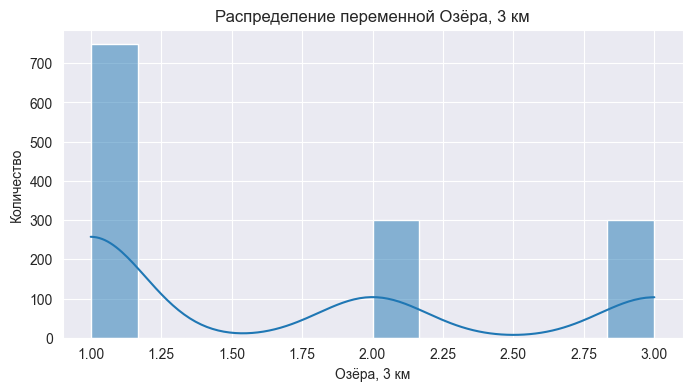

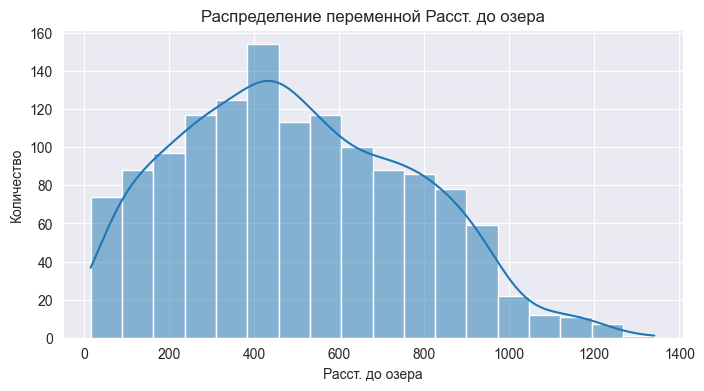

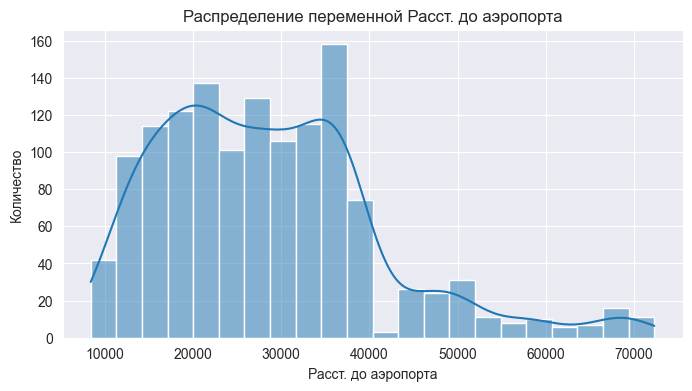

In [26]:
df_columns = df_big_ru.select_dtypes(include=['float64', 'int64']).columns
for column in df_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_big_ru[column], kde=True) 
    plt.title(f'Распределение переменной {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.show()

In [27]:
median_up_cell = float(df_big_ru["Выс. потолка"].median())
df_big_ru["Выс. потолка"] = np.where(df_big_ru["Выс. потолка"] > 4, median_up_cell, df_big_ru["Выс. потолка"])
median_up = float(df_big_ru["Выс. потолка"].median())
df_big_ru["Выс. потолка"] = np.where(df_big_ru["Выс. потолка"] < 2.3, median_up, df_big_ru["Выс. потолка"])

In [28]:
df_big_ru["Этажей в доме"] = df_big_ru["Этажей в доме"].astype(int)
df_big_ru["Количество комнат"] = df_big_ru["Количество комнат"].astype(int)
df_big_ru["Балкон"] = df_big_ru["Балкон"].astype(int)
df_big_ru["Этаж"] = df_big_ru["Этаж"].astype(int)
df_big_ru["Озёра, 3 км"] = df_big_ru["Озёра, 3 км"].astype(int)
df_big_ru["Парки, 3 км"] = df_big_ru["Парки, 3 км"].astype(int)

In [29]:
df_big_ru.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1349 entries, 13 to 23693
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Цена                    1349 non-null   float64
 1   Общая площадь           1349 non-null   float64
 2   Жилая площадь           1349 non-null   float64
 3   Количество комнат       1349 non-null   int64  
 4   Этаж                    1349 non-null   int64  
 5   Этажей в доме           1349 non-null   int64  
 6   Пл. кухни               1349 non-null   float64
 7   Выс. потолка            1349 non-null   float64
 8   Балкон                  1349 non-null   int64  
 9   Расст. к центру города  1349 non-null   float64
 10  Парки, 3 км             1349 non-null   int64  
 11  Расст. до парка         1349 non-null   float64
 12  Озёра, 3 км             1349 non-null   int64  
 13  Расст. до озера         1349 non-null   float64
 14  Расст. до аэропорта     1349 non-null   flo

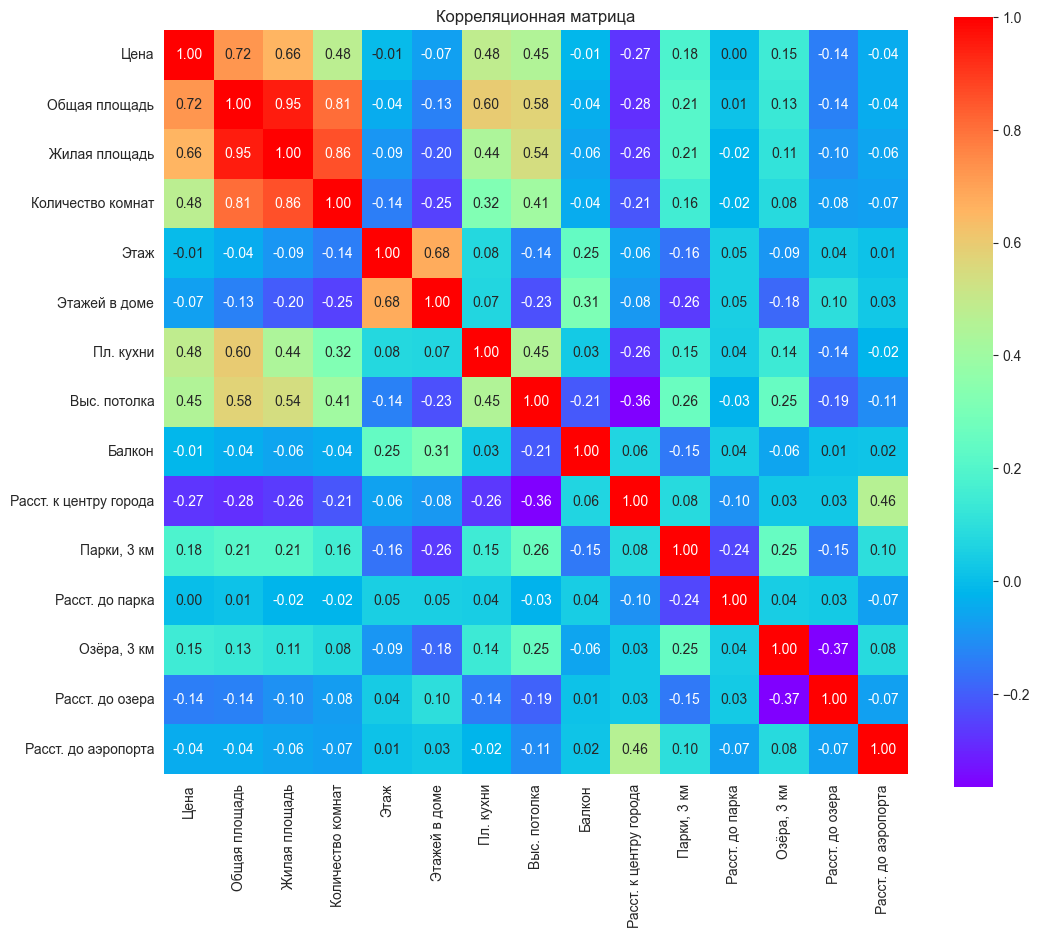

In [30]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_big_ru.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='rainbow', square=True)
plt.title('Корреляционная матрица')
plt.show()

- Данная выборка более точно показывает влияние факторов на цену квартиры - хотя по-прежнему самыми весомыми являются - общая площадь, жилая площадь и чуть менее значимым количество комнат
- С таким же точно коэффициентом у нас фактор размера кухни - 0.48 - что говорит о том, что данная выборка показывает более точные результаты нежели более маленькая, предыдущая
- Также, очень ярко теперь проявляется фактор Расстояния до центра города - и мы видим, что коэффициент почти 0.30, всего на треть меньше чем фактор размера кухни и количеством комнат. 
- Факторы Расстояние до озера, и Количество озёр в радиусе 3000 км практически сравнялись - и видимо практически равнозначны, так как в одном случае у нас появляется выбор - куда поехать, а в другом - близость к озеру, пусть оно и одно
- Но парки оказались более значимым фактором в составе цены за квартиры, в рамках предложений - то есть количество парков в радиусе 3000 км имеет важное значение, а вот фактор расстояния до парка - в матрице не проявился никак
- Выяснили, что фактор "Высота потолка" был с выбросом в 100 метров, убрали этот момент - заменив на среднее. В таком случае - Высота потолков коррелирует с ценой на квартиру примерно также, как и "Площадь кухни".
- Расстояние же до аэропорта оказалось почти вдвое менее важным для цены, Этажность дома или Высота потолков - ну и понятно, не все летают каждый день, а близость к аэропорту это не только удобство, но и шум, неудобство из-за пробок и тд.
- Вообще, если рассматривать сам фактор "Расстояние до аэропорта" - то он коррелирует только с расстоянием от центра города - ведь аэропорты чаще расположены вдали от центра, чтобы обеспечить нормальную работу аэропорта, также не доставлять неудобства жителям города
- Также, по поводу фактора "Расстояние до аэропорта" - он ещё коррелирует с расстоянием к озёрам и количеством озёр - и здесь опять же логично, так как чаще всего озёра располагаются за чертой города, либо дальше от центра города
- Итак, в новой выборке - средняя цена на квартиры выше, чем в предыдущей, примерно 9.4 миллиона, перцентили тоже ведут себя более интересно: 25й - 4.4, 50й - 6, 75й - 9.4, а 95й - более 26 миллионов. Самая дешёвая квартира в районе 2.1 миллиона, а самая дорогая - более 180 миллионов
- Замечено 4 выброса цены - 180, 160, 130, 124 миллиона соответственно
- Основное количество предложений находится в районе до 20 миллионов рублей
- Как и обещали позже разложим на группы все квартиры - 1, 2, 3 отдельно, а также 4, и больше 5 - узнаем какое количество у нас в выборке таких квартир, а также среднюю цену квартиры в каждой группе. 

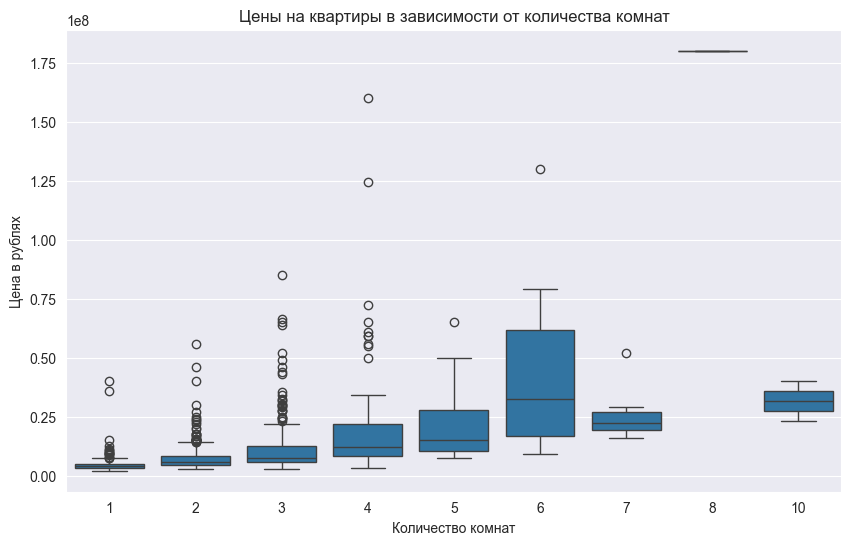

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Количество комнат", y="Цена", data=df_big_ru)
plt.title('Цены на квартиры в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена в рублях')
plt.show()

- Как видно из графика - однокомнатные квартиры чаще дешёвые, чем дорогие, и их цена зачастую не превышает 20 миллионов, но есть исключения - которые стоят на порядок дороже в категории от 25 до 50 миллионов
- Двухкомнатные же квартиры начинают примерно в районе 15 миллионов, и их стоимость до 30 миллионов плюс-минус, но есть некоторые выбросы - 40-50, и даже 60 миллионов
- Трёхкомнатные начинают с цены около 20 миллионов, и в среднем до 35 миллионов стоят, но есть вторая группа трёшек - достаточно много стоят от 40 и выше 50ти, а есть выброс на свыше 80 миллионов
- С четырёхкомнатными дело обстоит так, что начинаются предложения в районе 50 миллионов, но основная часть это от 60 до 70+, есть также выбросы - как раз 124 и 160
- 5-комнатная одна квартира в районе 70 миллионов, 6-комнатная - 130 миллионов, 7-комнатная 50 с хвостиком (что странно), но предположим, что там небольшая площадь комнат и удалённо от центра и все остальные факторы цены - тогда можно предположить что такое может быть, учитывая что 5-6 комнатных квартир у нас не так много. И 10-комнатная - 180 миллионов

- На графике выше мы видим, что одна группа до 50 квадратных метров, вторая до 100 квадратных - и это большинство в нашей выборке - цена на них в основном до 25 миллионов, не обошлось и без выбросов - они выше отметки 75 миллионов
- Достаточно большое количество предложений у нас в диапазоне 100-150 квадратных метров - цены здесь выше, но не намного, а вот выбросы до 160 миллионов
- От 150 до 200 квадратных метров - тоже достаточно много предложений, хотя учитывая нашу большую выборку в почти 1500 значений - примерно 1% её - но всё же, здесь разные колебания цены от 20 миллионов до 70, выбросов нет
- В категориях 200+ и 250+ всего две квартиры, одна менее 20 миллионов (что очень странно), а вторая - та самая за 180 миллионов, что является самым дорогим предложением в нашей выборке

In [32]:
df_big_ru.columns

Index(['Цена', 'Общая площадь', 'Жилая площадь', 'Количество комнат', 'Этаж',
       'Этажей в доме', 'Пл. кухни', 'Выс. потолка', 'Балкон',
       'Расст. к центру города', 'Парки, 3 км', 'Расст. до парка',
       'Озёра, 3 км', 'Расст. до озера', 'Расст. до аэропорта'],
      dtype='object')

Построим гипотезу, что цена квартиры положительно коррелирует с общей площадью, а значит или не значит и с жилой площадью. Для этого построим графики и сделаем вывод 

Корреляция между ценой и площадью: 0.72


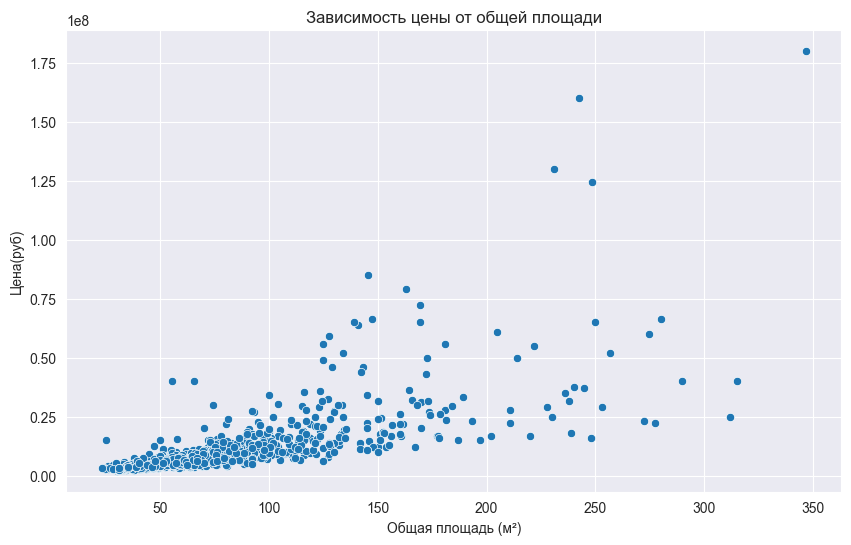

In [33]:
correlation = df_big_ru['Цена'].corr(df_big_ru['Общая площадь'])
print(f"Корреляция между ценой и площадью: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Общая площадь', y='Цена', data=df_big_ru)
plt.title('Зависимость цены от общей площади')
plt.xlabel('Общая площадь (м²)')
plt.ylabel('Цена(руб)')
plt.show()

Корреляция между ценой и площадью: 0.66


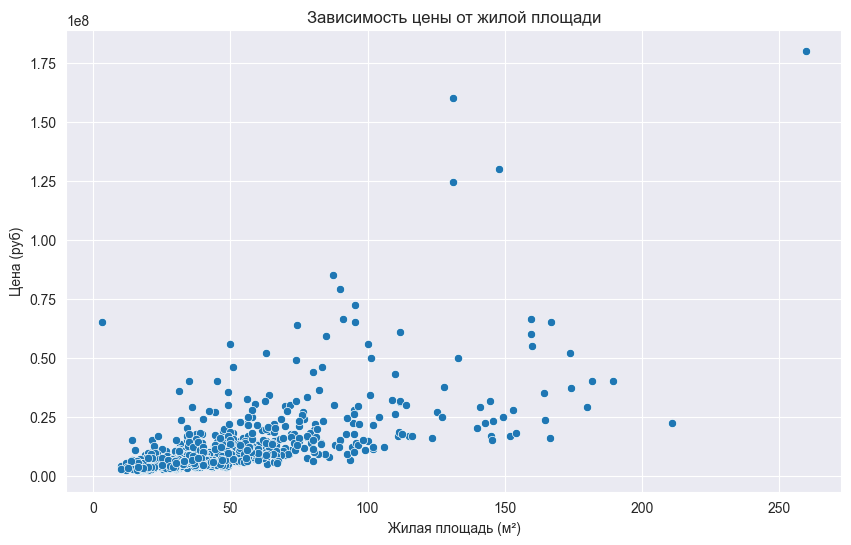

In [33]:
correlation = df_big_ru['Цена'].corr(df_big_ru['Жилая площадь'])
print(f"Корреляция между ценой и площадью: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Жилая площадь', y='Цена', data=df_big_ru)
plt.title('Зависимость цены от жилой площади')
plt.xlabel('Жилая площадь (м²)')
plt.ylabel('Цена (руб)')
plt.show()

Всё, как мы и описывали по нашей корреляционной матрице - корреляция налицо - и составляет 0.72 если рассматривать общую и 0.66, если всё-таки учитывать жилую площадь. То есть, наша гипотеза доказана - размер квартиры, даже общая площадь реально поднимают цену, позволяя продавцу дороже продать, а покупателю придётся за большие метры больше заплатить

In [35]:
df_big_ru.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1349 entries, 13 to 23693
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Цена                    1349 non-null   float64
 1   Общая площадь           1349 non-null   float64
 2   Жилая площадь           1349 non-null   float64
 3   Количество комнат       1349 non-null   int64  
 4   Этаж                    1349 non-null   int64  
 5   Этажей в доме           1349 non-null   int64  
 6   Пл. кухни               1349 non-null   float64
 7   Выс. потолка            1349 non-null   float64
 8   Балкон                  1349 non-null   int64  
 9   Расст. к центру города  1349 non-null   float64
 10  Парки, 3000 км          1349 non-null   int64  
 11  Расст. до парка         1349 non-null   float64
 12  Озёра, 3000 км          1349 non-null   int64  
 13  Расст. до озера         1349 non-null   float64
 14  Расст. до аэропорта     1349 non-null   flo

In [34]:
for col in df_big_ru.columns:
    if col != 'Цена':
        if df_big_ru[col].dtype == 'int64':
            df_big_ru[col] = df_big_ru[col].astype('int16')
        elif df_big_ru[col].dtype == 'float64':    
            df_big_ru[col] = df_big_ru[col].astype('float16')

pd.set_option('display.float_format', '{:,.2f}'.format)


C:\Users\shoot\AppData\Roaming\Python\Python312\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


In [35]:
df_big_ru.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1349 entries, 13 to 23693
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Цена                    1349 non-null   float64
 1   Общая площадь           1349 non-null   float16
 2   Жилая площадь           1349 non-null   float16
 3   Количество комнат       1349 non-null   int16  
 4   Этаж                    1349 non-null   int16  
 5   Этажей в доме           1349 non-null   int16  
 6   Пл. кухни               1349 non-null   float16
 7   Выс. потолка            1349 non-null   float16
 8   Балкон                  1349 non-null   int16  
 9   Расст. к центру города  1349 non-null   float16
 10  Парки, 3 км             1349 non-null   int16  
 11  Расст. до парка         1349 non-null   float16
 12  Озёра, 3 км             1349 non-null   int16  
 13  Расст. до озера         1349 non-null   float16
 14  Расст. до аэропорта     1349 non-null   flo

Приведя нашу выборку к 16-битному виду - мы с 169 килобайта, оптимизировали до 58, что более чем на 65% меньше исходного варианта с 64-битными показателями

В ходе нашего аналитического эксперимента мы отталкивались от логики, что нам нужны более чистые данные, чтобы построить нашу аналитическую модель. Выяснили также что апартаменты по сути столбец, который слишком грязный - и верных значений по нему нет, а стало быть открытый план и студия, что тоже достаточно грязные нами тоже не выводятся. Так как мы не имеем возможности сравнивать цены на квартиры из-за планировки, то мы отталкиваемся от оставшихся факторов. В первом случае мы получили 269 вариантов, во-втором 1349 варианта. Но что если посмотреть альтернативный путь преобразования нашего датафрейма, где грязные данные в виде факторов с расстоянием до - заменить на среднее в данном столбце. Что получим в результате такой очистки. Сейчас и узнаем.

In [36]:
df_dirty = df_big

В результате мы получаем выборку из 23.699 значений. Осталось теперь совершить все те же действия, за исключением того, что теперь у нас есть больше значений, а также что с бывшими пропусками нужно поработать более тщательней

In [37]:
def replace_nan_with_median(df, column_name):
    if column_name in df.columns:
        if column != 'Цена':
            median_value = df[column_name].median()
            df_dirty[column_name].fillna(median_value, inplace=True)


for column in df_dirty.columns:
   replace_nan_with_median(df_dirty, column)


C:\Users\shoot\AppData\Local\Temp\ipykernel_17256\611903231.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_dirty[column_name].fillna(median_value, inplace=True)
C:\Users\shoot\AppData\Local\Temp\ipykernel_17256\611903231.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [38]:
df_ru = df_dirty.rename(columns={
    "last_price": "Цена", 
    "total_area": "Общая площадь", 
    "living_area": "Жилая площадь", 
    "rooms": "Количество комнат",
    "floor": "Этаж",
    "floors_total": "Этажей в доме",
    "kitchen_area": "Пл. кухни",
    "ceiling_height": "Выс. потолка",
    "balcony": "Балкон",
    "cityCenters_nearest": "Расст. к центру города",
    "parks_around3000": "Парки, 3 км",
    "parks_nearest": "Расст. до парка",
    "ponds_around3000": "Озёра, 3 км",
    "ponds_nearest": "Расст. до озера",
    "airports_nearest": "Расст. до аэропорта"
} )

In [39]:
df_pure = df_ru

In [40]:
df_pure

,Цена,Общая площадь,Жилая площадь,Количество комнат,Этаж,Этажей в доме,Пл. кухни,Выс. потолка,Балкон,Расст. к центру города,"Парки, 3 км",Расст. до парка,"Озёра, 3 км",Расст. до озера,Расст. до аэропорта
0,"13,000,000.00",108.00,51.00,3,8,16.00,25.00,2.70,1.00,"16,028.00",1.00,482.00,2.00,755.00,"18,863.00"
1,"3,350,000.00",40.40,18.60,1,1,11.00,11.00,2.65,2.00,"18,603.00",0.00,455.00,0.00,502.00,"12,817.00"
2,"5,196,000.00",56.00,34.30,2,4,5.00,8.30,2.65,0.00,"13,933.00",1.00,90.00,2.00,574.00,"21,741.00"
3,"64,900,000.00",159.00,30.00,3,9,14.00,9.10,2.65,0.00,"6,800.00",2.00,84.00,3.00,234.00,"28,098.00"
4,"10,000,000.00",100.00,32.00,2,13,14.00,41.00,3.03,1.00,"8,098.00",2.00,112.00,1.00,48.00,"31,856.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,"9,700,000.00",133.81,73.30,3,3,5.00,13.83,3.70,1.00,"4,232.00",1.00,796.00,3.00,381.00,"24,665.00"
23695,"3,100,000.00",59.00,38.00,3,4,5.00,8.50,2.65,1.00,"13,098.50",0.00,455.00,1.00,502.00,"26,726.00"
23696,"2,500,000.00",56.70,29.70,2,1,3.00,9.10,2.65,1.00,"13,098.50",0.00,455.00,1.00,502.00,"26,726.00"
23697,"11,475,000.00",76.75,30.00,2,12,17.00,23.30,3.00,2.00,"10,364.00",2.00,173.00,3.00,196.00,"39,140.00"


In [41]:
median_up_cell = float(df_pure["Выс. потолка"].median())
df_pure["Выс. потолка"] = np.where(df_pure["Выс. потолка"] > 4, median_up_cell, df_pure["Выс. потолка"])
df_pure["Выс. потолка"] = np.where(df_pure["Выс. потолка"] < 2.3, median_up_cell, df_pure["Выс. потолка"])

In [42]:
df_pure["Этажей в доме"] = df_pure["Этажей в доме"].astype(int)
df_pure["Балкон"] = df_pure["Балкон"].astype(int)
df_pure["Озёра, 3 км"] = df_pure["Озёра, 3 км"].astype(int)
df_pure["Парки, 3 км"] = df_pure["Парки, 3 км"].astype(int)

In [43]:
df_pure.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Цена                    23699 non-null  float64
 1   Общая площадь           23699 non-null  float64
 2   Жилая площадь           23699 non-null  float64
 3   Количество комнат       23699 non-null  int64  
 4   Этаж                    23699 non-null  int64  
 5   Этажей в доме           23699 non-null  int64  
 6   Пл. кухни               23699 non-null  float64
 7   Выс. потолка            23699 non-null  float64
 8   Балкон                  23699 non-null  int64  
 9   Расст. к центру города  23699 non-null  float64
 10  Парки, 3 км             23699 non-null  int64  
 11  Расст. до парка         23699 non-null  float64
 12  Озёра, 3 км             23699 non-null  int64  
 13  Расст. до озера         23699 non-null  float64
 14  Расст. до аэропорта     23699 non-null

In [44]:
missing = df_pure.isnull().sum()
print("\nКоличество пропущенных значений в каждом столбце:", len(missing[missing > 0]))
duplicate_rows = df_pure[df_pure.duplicated(keep=False)]
print("\nКоличество дублирующих строк:", len(duplicate_rows))


Количество пропущенных значений в каждом столбце: 0

Количество дублирующих строк: 4


In [48]:
duplicate_rows

,Цена,Общая площадь,Жилая площадь,Количество комнат,Этаж,Этажей в доме,Пл. кухни,Выс. потолка,Балкон,Расст. к центру города,"Парки, 3 км",Расст. до парка,"Озёра, 3 км",Расст. до озера,Расст. до аэропорта
4965,"1,700,000.00",44.00,30.00,2,3,5,6.00,2.50,1,"13,098.50",0,455.00,1,502.00,"26,726.00"
9661,"2,533,531.00",42.50,19.80,1,7,18,9.10,2.56,1,"13,098.50",0,455.00,1,502.00,"26,726.00"
9886,"2,533,531.00",42.50,19.80,1,7,18,9.10,2.56,1,"13,098.50",0,455.00,1,502.00,"26,726.00"
13379,"1,700,000.00",44.00,30.00,2,3,5,6.00,2.50,1,"13,098.50",0,455.00,1,502.00,"26,726.00"


In [45]:
df_pure.drop([4965, 9661], axis=0, inplace=True)

In [46]:
duplicate_rows = df_pure[df_pure.duplicated(keep=False)]
print("\nКоличество дублирующих строк:", len(duplicate_rows))


Количество дублирующих строк: 0


В результате нашли 2 полностью дублирующие строки - такого совпадения точного быть, как нам кажется, не должно - ведь каждый параметр совпадает точь-в-точь - поэтому мы их удаляем, и получаем выборку из 23697 значений. Видим также что факторы такие как количество озёр парков в основном заменились на 0, те которые были изначально неизвестными. 

In [47]:
df_pure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23697 entries, 0 to 23698
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Цена                    23697 non-null  float64
 1   Общая площадь           23697 non-null  float64
 2   Жилая площадь           23697 non-null  float64
 3   Количество комнат       23697 non-null  int64  
 4   Этаж                    23697 non-null  int64  
 5   Этажей в доме           23697 non-null  int64  
 6   Пл. кухни               23697 non-null  float64
 7   Выс. потолка            23697 non-null  float64
 8   Балкон                  23697 non-null  int64  
 9   Расст. к центру города  23697 non-null  float64
 10  Парки, 3 км             23697 non-null  int64  
 11  Расст. до парка         23697 non-null  float64
 12  Озёра, 3 км             23697 non-null  int64  
 13  Расст. до озера         23697 non-null  float64
 14  Расст. до аэропорта     23697 non-null  flo

Размер данной выборки составляет почти 3 мегабайта. Попробуем её привести к 16-битному виду, не трогая фактор Цены, который может включать в себя большие числа, что не помещаются в 16-битный формат

In [48]:
for column in df_pure.columns:
    if column != 'Цена':
        if df_pure[column].dtype == 'int64':
            df_pure[column] = df_pure[column].astype('int16')
        elif df_pure[column].dtype == 'float64':    
            df_pure[column] = df_pure[column].astype('float16')

pd.set_option('display.float_format', '{:,.2f}'.format)

C:\Users\shoot\AppData\Roaming\Python\Python312\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
C:\Users\shoot\AppData\Roaming\Python\Python312\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


In [49]:
df_pure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23697 entries, 0 to 23698
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Цена                    23697 non-null  float64
 1   Общая площадь           23697 non-null  float16
 2   Жилая площадь           23697 non-null  float16
 3   Количество комнат       23697 non-null  int16  
 4   Этаж                    23697 non-null  int16  
 5   Этажей в доме           23697 non-null  int16  
 6   Пл. кухни               23697 non-null  float16
 7   Выс. потолка            23697 non-null  float16
 8   Балкон                  23697 non-null  int16  
 9   Расст. к центру города  23697 non-null  float16
 10  Парки, 3 км             23697 non-null  int16  
 11  Расст. до парка         23697 non-null  float16
 12  Озёра, 3 км             23697 non-null  int16  
 13  Расст. до озера         23697 non-null  float16
 14  Расст. до аэропорта     23697 non-null  flo

Таким образом мы уменьшили нашу выборку с 2.9 Мб до чуть более 1 мегабайта, что примерно на 65% уменьшило размер нашей выборки

In [50]:
max_rooms = df_pure[df_pure["Количество комнат"] >= 11]

Нами также замечены странные значения в параметре "Количество комнат" - мы вывели значение этого параметра больше или равно 11, ведь в прошлых, более меньших выборках, таких значений нами не наблюдалось - получили 8 таких строк, считаем что их тоже необходимо удалить, так как это существенных выброс в нашем исследовании

In [51]:
df_pure = df_pure.drop(max_rooms.index)

Итого, у нас теперь 23689 значений в нашей выборке

Заметили также, что в столбцах "Расстояние до аэропорта" и "Расстояние до центра города" появился вывод info - это значит, что 16-битная система вывода не срабатывает для некоторых значений в этих столбцах. У нас есть два варианта - удалить такие значения - если их немного, либо преобразовать в 32-битную систему вывода и хранения данных. Такие же значения приняли среднее по данным столбцам и максимальное значения - что дял нас скорее выброс, чем нужные данные. Выведем количество таких результатов, и подумаем как поступить в данной ситуации. Также заметили, что мы пропустили момент того, что в датафрейме вывод значений производится через разные разделители - где-то через запятую, а где-то через точку. Нас такая картина не устраивает, поэтому приведём все строчки к единому выводу с помощью запятой.

In [52]:
df_pure.replace('.',',')

,Цена,Общая площадь,Жилая площадь,Количество комнат,Этаж,Этажей в доме,Пл. кухни,Выс. потолка,Балкон,Расст. к центру города,"Парки, 3 км",Расст. до парка,"Озёра, 3 км",Расст. до озера,Расст. до аэропорта
0,"13,000,000.00",108.00,51.00,3,8,16,25.00,2.70,1,"16,032.00",1,482.00,2,755.00,"18,864.00"
1,"3,350,000.00",40.41,18.59,1,1,11,11.00,2.65,2,"18,608.00",0,455.00,0,502.00,"12,816.00"
2,"5,196,000.00",56.00,34.31,2,4,5,8.30,2.65,0,"13,936.00",1,90.00,2,574.00,"21,744.00"
3,"64,900,000.00",159.00,30.00,3,9,14,9.10,2.65,0,"6,800.00",2,84.00,3,234.00,"28,096.00"
4,"10,000,000.00",100.00,32.00,2,13,14,41.00,3.03,1,"8,096.00",2,112.00,1,48.00,"31,856.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,"9,700,000.00",133.75,73.31,3,3,5,13.83,3.70,1,"4,232.00",1,796.00,3,381.00,"24,672.00"
23695,"3,100,000.00",59.00,38.00,3,4,5,8.50,2.65,1,"13,096.00",0,455.00,1,502.00,"26,720.00"
23696,"2,500,000.00",56.69,29.70,2,1,3,9.10,2.65,1,"13,096.00",0,455.00,1,502.00,"26,720.00"
23697,"11,475,000.00",76.75,30.00,2,12,17,23.30,3.00,2,"10,368.00",2,173.00,3,196.00,"39,136.00"


Теперь мы точно уверены, что в строках не окажется лишних точек - только те, что будут показывать числа до определённого значения равного 1000. Перевод в километры значения расстояний тоже не считаем нужным осуществлять, так как есть значения меньше километра

In [53]:
df_pure[df_pure["Жилая площадь"] <= 5]

,Цена,Общая площадь,Жилая площадь,Количество комнат,Этаж,Этажей в доме,Пл. кухни,Выс. потолка,Балкон,Расст. к центру города,"Парки, 3 км",Расст. до парка,"Озёра, 3 км",Расст. до озера,Расст. до аэропорта
3242,"4,440,000.00",41.00,3.00,1,17,17,11.00,2.65,1,"13,072.00",0,455.00,0,502.00,"19,264.00"
13915,"6,350,000.00",52.00,2.00,2,2,6,9.00,3.00,1,"6,520.00",0,455.00,1,"1,012.00","32,448.00"
17582,"2,680,000.00",22.00,5.00,0,8,25,9.10,2.65,2,"11,616.00",1,835.00,1,652.00,"22,736.00"
21758,"2,330,000.00",23.00,2.00,0,22,24,9.10,2.65,1,"13,096.00",0,455.00,1,502.00,"26,720.00"
23574,"64,990,000.00",139.00,3.00,3,8,8,16.00,3.00,1,"5,976.00",1,630.00,3,100.00,"33,248.00"


Найдено 5 квартир с жилой площадью менее 5 метров, при этом Общая площадь составляет от 22 до 139 метров. Считаем эти данные некорректными, так как это не первый этаж - чтобы подумать о варианте помещения для бизнеса - при том что показатель количества комнат есть ноль в двух случаях. Единственный такой возможный вариант мог бы быть вариант на 17 этаже 17этажного дома - индекс, 3242. Но, из 42 квадратных метров всего 3 жилая площадь - будет скорее выбросом в нашей выборке, чем нужным дял анализа значением. Поэтому такие значения мы удаляем

In [54]:
no_fact_live = df_pure[df_pure["Жилая площадь"] <= 5]

In [55]:
df_pure = df_pure.drop(no_fact_live.index, axis=0)

Теперь у нас уже выборка из 23.684 значений. Посмотрим не превышает ли жилая площадь общую - ведь это совсем нелогично, а также не находятся ли выше квартиры, чем этажность дома

In [56]:
anomaly =  df_pure[df_pure["Жилая площадь"] > df_pure["Общая площадь"]]

In [57]:
df_pure = df_pure.drop(anomaly.index)

Нами было найдено 77 значений, где жилая площадь была больше нежели общая площадь - что по логике вещей является аномалией. Мы удалили такие значения. В результате получили выборку с 23.607 значениями

In [58]:
df_pure[df_pure["Этаж"] > df_pure["Этажей в доме"]]

,Цена,Общая площадь,Жилая площадь,Количество комнат,Этаж,Этажей в доме,Пл. кухни,Выс. потолка,Балкон,Расст. к центру города,"Парки, 3 км",Расст. до парка,"Озёра, 3 км",Расст. до озера,Расст. до аэропорта
457,"9,788,348.00",70.81,38.41,2,12,9,10.63,2.65,0,"8,320.00",2,309.00,2,706.00,"37,376.00"
2392,"5,395,770.00",53.00,29.00,2,22,9,9.00,2.65,0,"10,816.00",0,455.00,0,502.00,"43,072.00"
2846,"2,325,000.00",27.80,19.41,1,15,9,9.10,2.65,0,"17,376.00",0,455.00,1,374.00,"22,048.00"
3031,"6,400,000.00",56.69,32.00,2,12,9,12.00,2.65,1,"13,096.00",0,455.00,1,502.00,"26,720.00"
3438,"4,100,000.00",38.00,19.00,1,12,9,10.30,2.65,1,"13,096.00",0,455.00,1,502.00,"26,720.00"
4617,"4,275,062.00",61.19,32.00,2,12,9,12.20,2.65,0,"17,376.00",0,455.00,1,374.00,"22,048.00"
4848,"13,000,000.00",98.00,30.00,3,18,9,9.10,2.65,0,"14,152.00",0,455.00,0,502.00,"37,632.00"
5146,"3,085,024.00",33.34,11.00,1,12,9,9.10,2.65,1,"25,872.00",1,400.00,1,492.00,"47,296.00"
5784,"4,262,941.00",59.91,31.70,2,18,9,11.90,2.65,0,"17,376.00",0,455.00,1,374.00,"22,048.00"
5958,"3,200,000.00",30.30,30.00,0,13,9,9.10,2.65,1,"11,616.00",1,835.00,1,652.00,"22,736.00"


Итак, видим, что при этажности в 9 этажей дома - квартиры оказываются гораздо выше, как минимум на 1 этаж, что нами расценивается как аномалия. Таких аномалий найдено 36 строк. Конечно же удалим и их тоже

In [59]:
anomaly_floor = df_pure[df_pure["Этаж"] > df_pure["Этажей в доме"]]

In [60]:
df_pure = df_pure.drop(anomaly_floor.index)

Получили в итоге выборку с 23571 значением

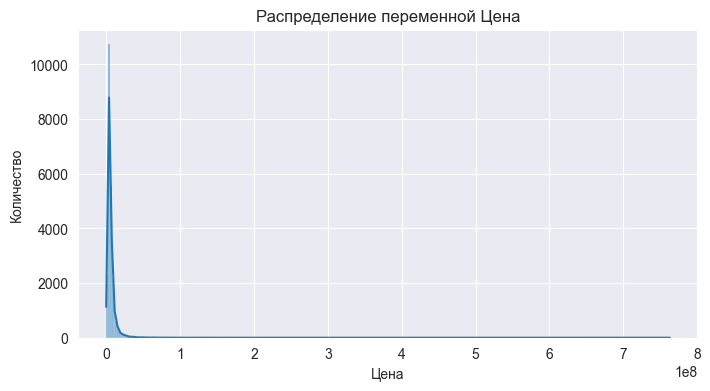

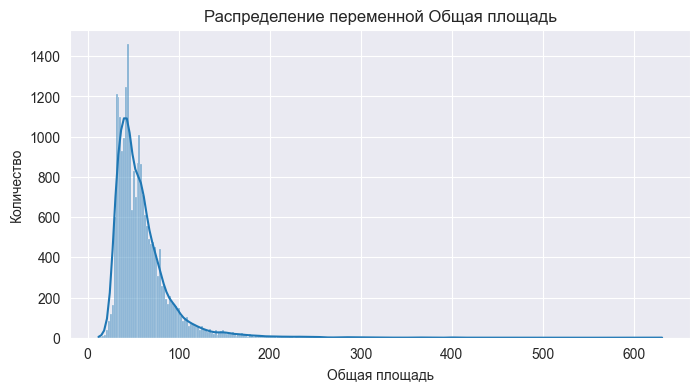

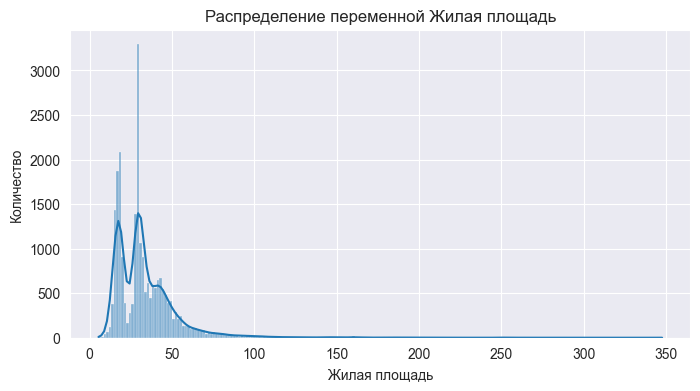

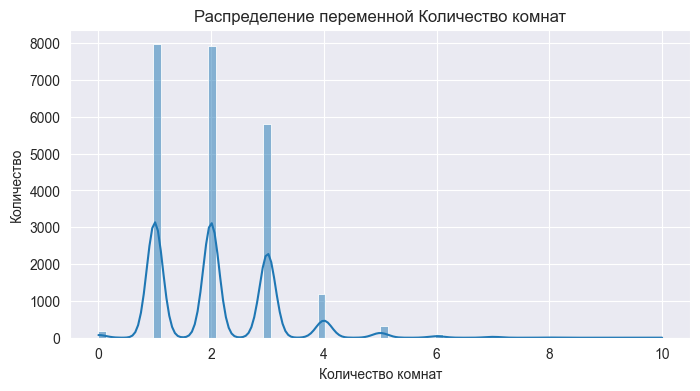

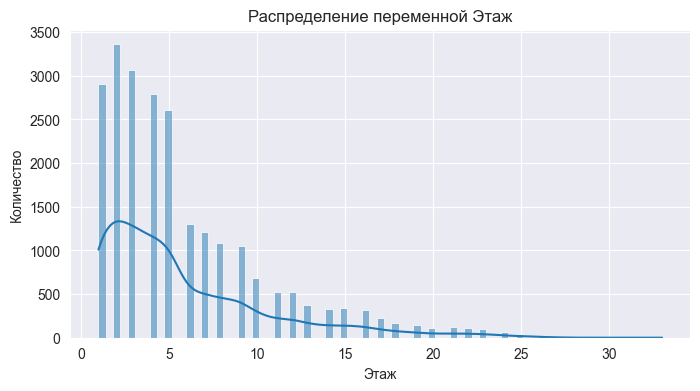

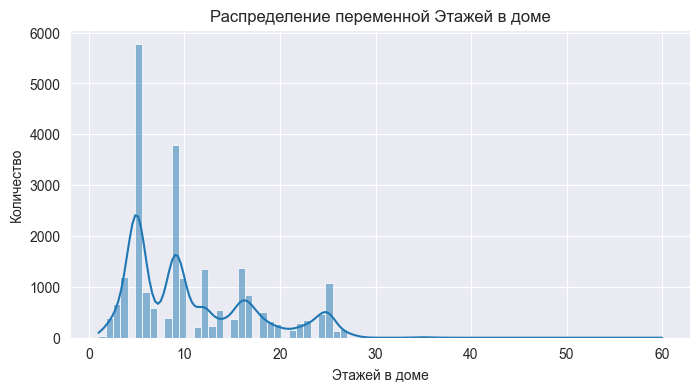

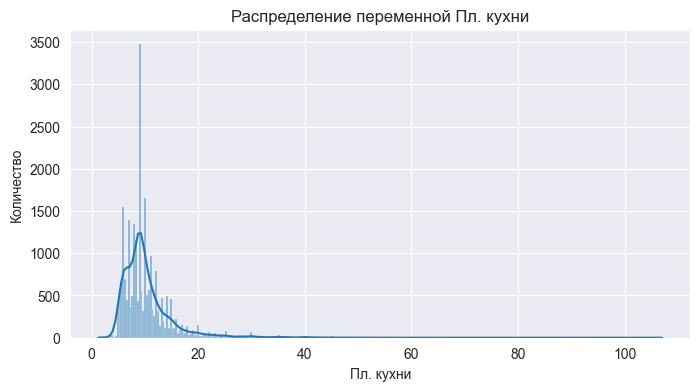

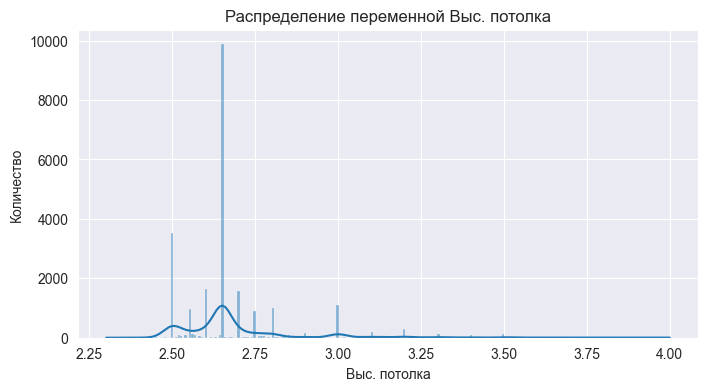

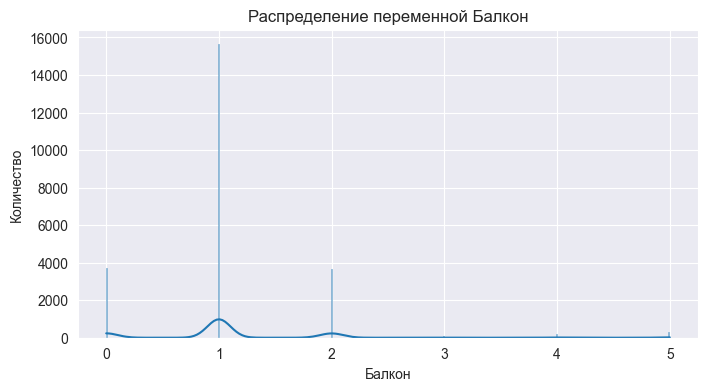

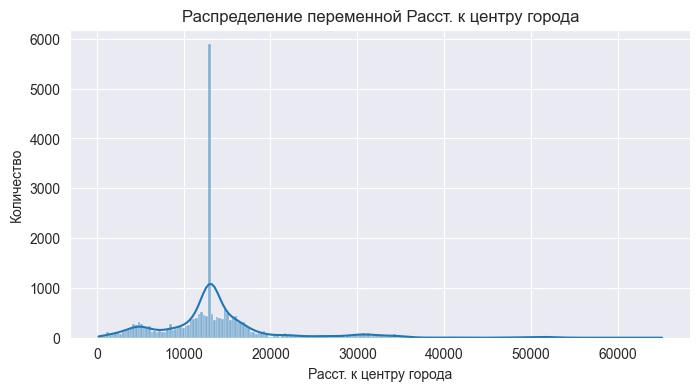

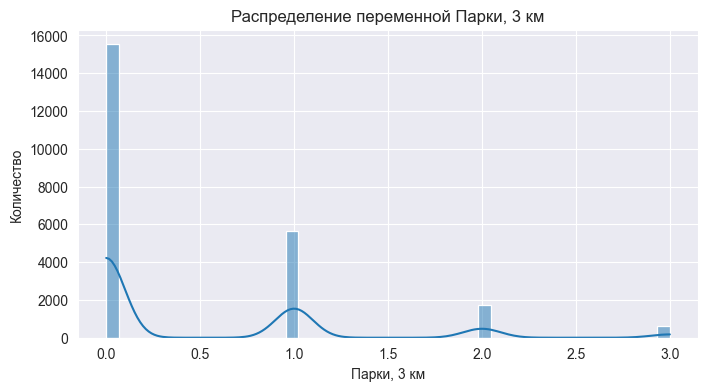

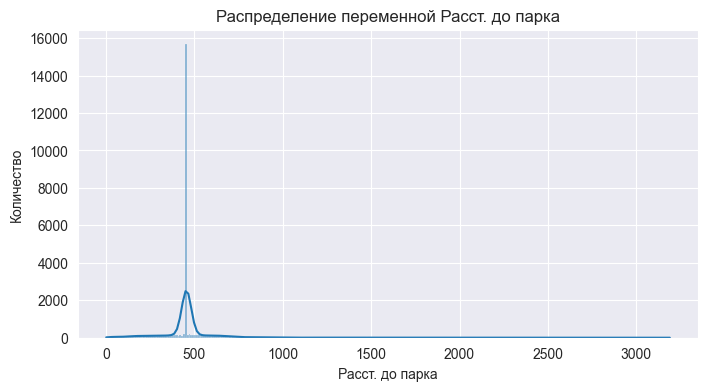

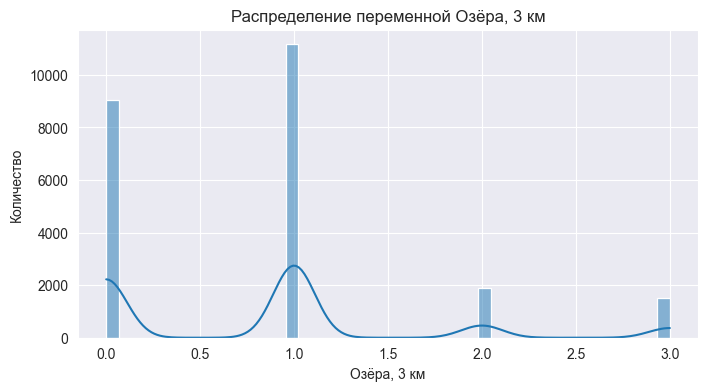

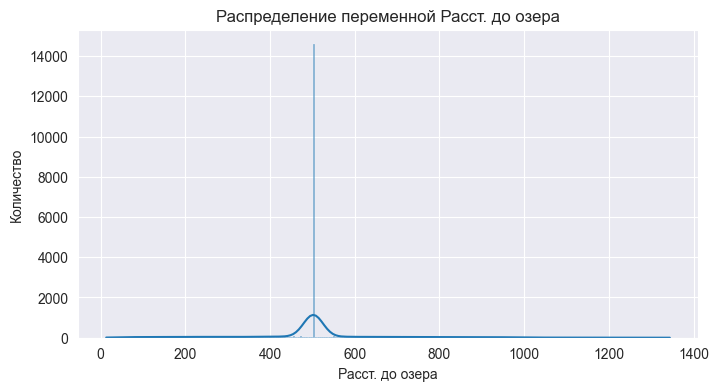

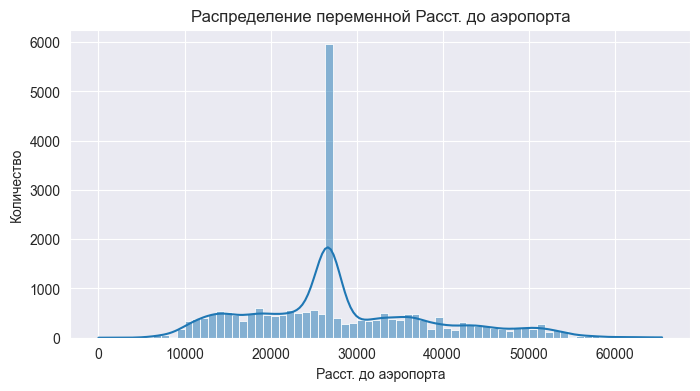

In [61]:
df_columns = df_pure.select_dtypes(include=['float64', 'int16', 'float16']).columns
for column in df_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_pure[column], kde=True) 
    plt.title(f'Распределение переменной {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.show()

Итак, уже на этих графиках мы видим, что в основном в выборке у нас мода Общая площади на 50 метрах квадратных, а вот Жилая площадь составляет моду - менее 50 метров квадратных. Мода количества комнат - на однокомнатных и двухкомнатных, с небольшим перевесом в сторону однокомнатных. В графике вывода этажности дома, понимаем что мода на 5-этажных домах, отсюда неудивительно, что мода этажа, на котором находится квартира - 3-4. Площадь кухни - мода около 10 метров, а высота потолков на моде 2.65 метра. Конечно, если вывести отдельно пятиэтажки, как группу, отдельно дома с этажностью ниже 5-го, а дома с этажностью выше 5-го - в третью группу - нам кажется, что ситуация была бы несколько иной. Балкон - мода 1 (что вполне логично), а удалённость от центра города на моде 13 км - притом, что это практически 4я часть выборки. В графиках, касающихся данных о парках две моды - парков 0 - в районе 3000 км - это одна, а вторая - парк находится в менее чем 500 метрах от дома - при том, что обе моды в районе 16000 предложений - отсюда можем сразу сделать вывод, что больше половины выборки - это дома, далеко от парков, как минимум более 3 км. С озёрами ситуация иная - мода расстояния до озера - более 500 метров, более 14000 предложений, и мода при количестве озёр 1 - в более 10000. Мода же расстояния до аэропорта никак не коррелирует с парками и озёрами, как было можно подумать на маленьких выборках, и находится в районе 27 км, с такими значениями около 25% выборки. И если мы вспомним, что до центра города - значение у нас тоже почти 25% выборки - сделаем гипотезу о том, что половина квартир находятся либо далеко от аэропорта, либо далеко от центра города, либо и то и другое вместе.

Корреляция между ценой и площадью: 0.53


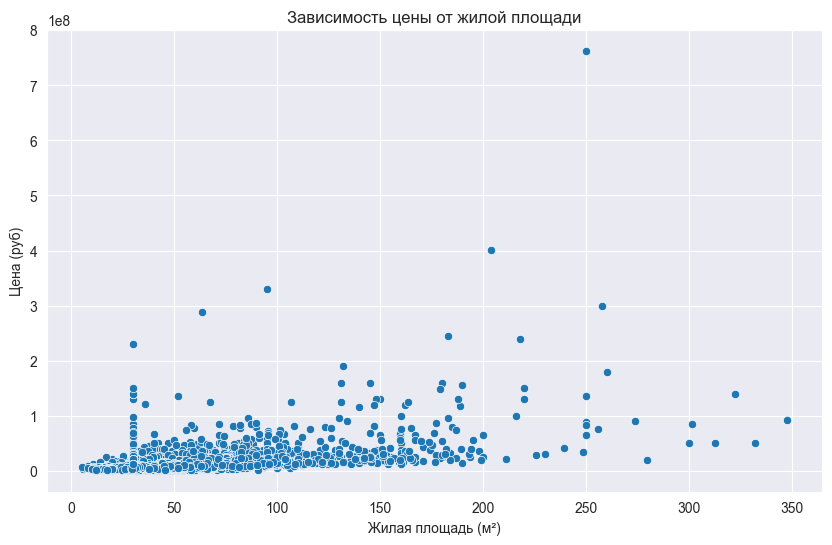

In [62]:
correlation = df_pure['Цена'].corr(df_pure['Жилая площадь'])
print(f"Корреляция между ценой и площадью: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Жилая площадь', y='Цена', data=df_pure)
plt.title('Зависимость цены от жилой площади')
plt.xlabel('Жилая площадь (м²)')
plt.ylabel('Цена (руб)')
plt.show()

Корреляция между ценой и площадью: 0.64


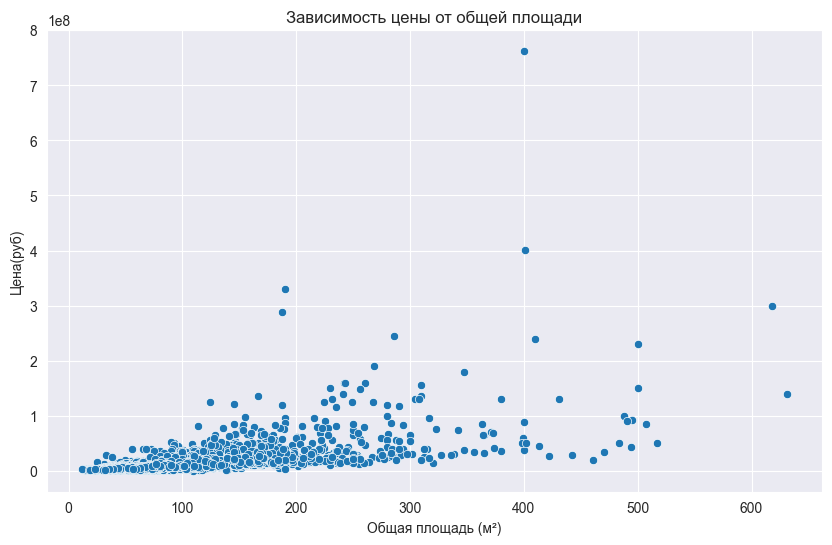

In [63]:
correlation = df_pure['Цена'].corr(df_pure['Общая площадь'])
print(f"Корреляция между ценой и площадью: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Общая площадь', y='Цена', data=df_pure)
plt.title('Зависимость цены от общей площади')
plt.xlabel('Общая площадь (м²)')
plt.ylabel('Цена(руб)')
plt.show()

Видим, что корреляция общей площади к цене - 0.64, а жилой площади 0.53. Но так ли это в корреляции общей к жилой площади? То есть что цена общей площади добавляет к цене за жилую 21% стоимости, которую платит покупатель. И при этом только 87% стоимости жилой площади коррелирует показателем общей площади.

Корреляция между общей и жилой площадью: 0.87


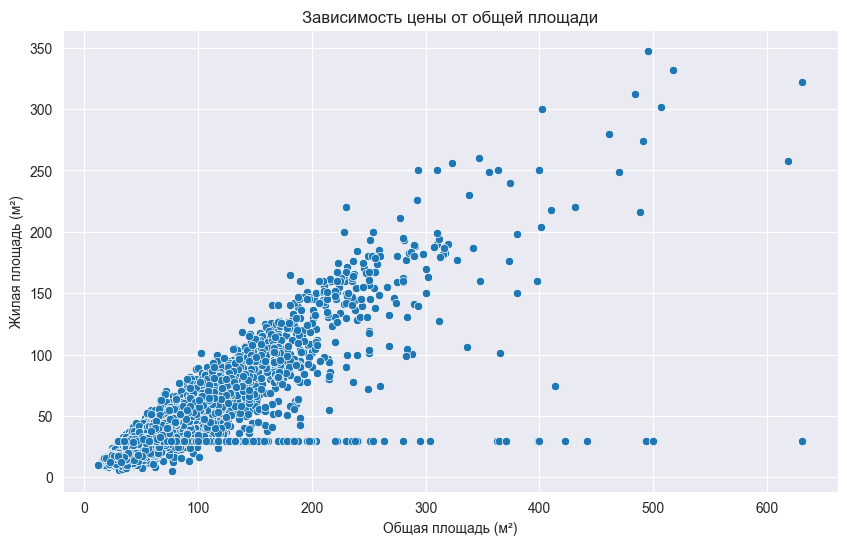

In [64]:
correlation = df_pure['Общая площадь'].corr(df_pure['Жилая площадь'])
print(f"Корреляция между общей и жилой площадью: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Общая площадь', y='Жилая площадь', data=df_pure)
plt.title('Зависимость цены от общей площади')
plt.xlabel('Общая площадь (м²)')
plt.ylabel('Жилая площадь (м²)')
plt.show()

Да, как видим - так и есть. Хотя, в больших цифрах - существует выбросы.

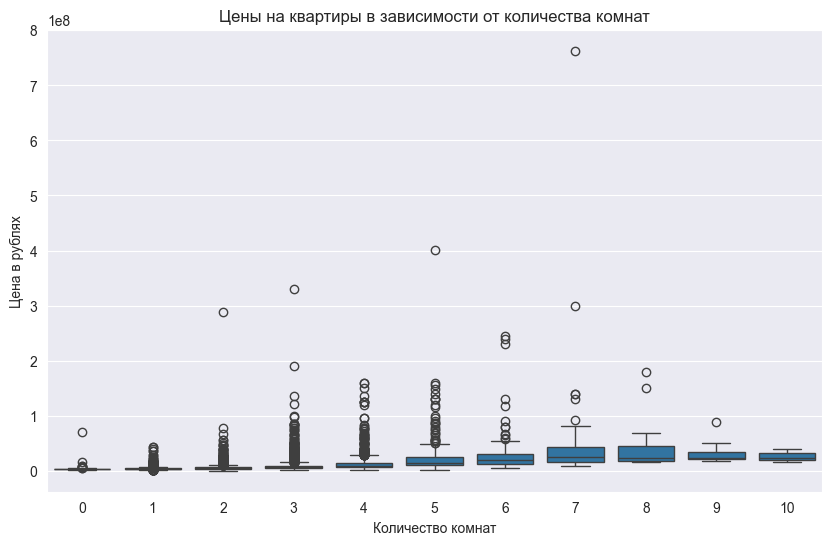

In [65]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Количество комнат", y="Цена", data=df_pure)
plt.title('Цены на квартиры в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена в рублях')
plt.show()

In [66]:
nul_rooms = df_pure[df_pure["Количество комнат"] == 0]

В результате вывода, на графике мы обнаружили что у нас есть квартиры с 0 комнат, что конечно является нелогичным, ведь квартиры состоят из комнат. Поэтому такие строки - 184 шт. - тоже удаляем

In [67]:
df_pure = df_pure.drop(nul_rooms.index)

Итого получили 23.387 значений. Попробуем снова посмотреть как количество комнат влияет на цену квартиры

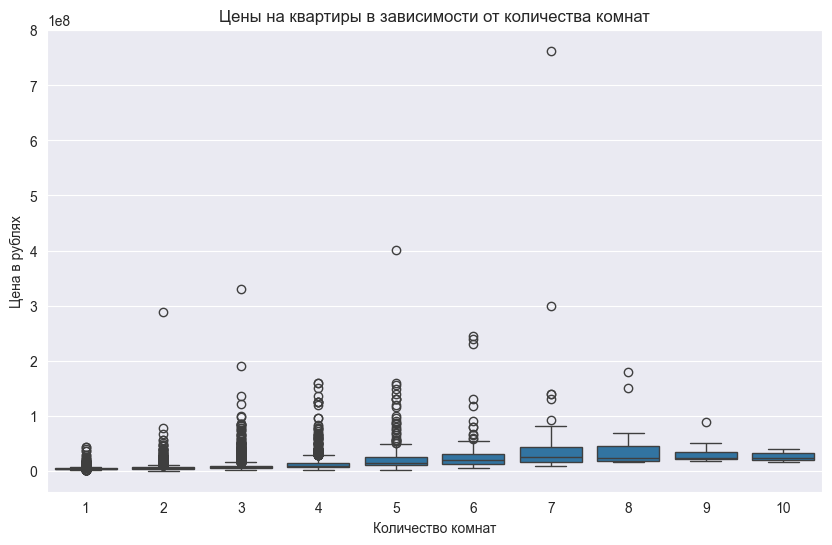

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Количество комнат", y="Цена", data=df_pure)
plt.title('Цены на квартиры в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена в рублях')
plt.show()

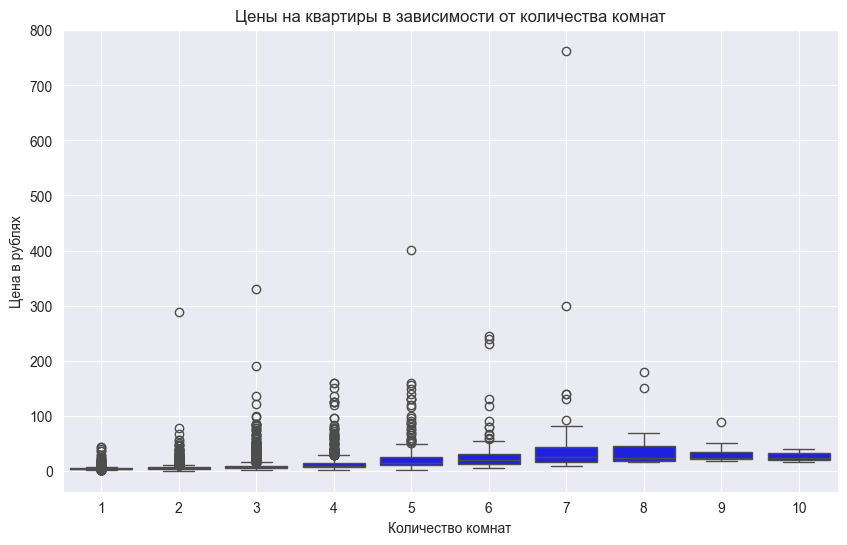

In [69]:
df_pure['Цена в миллионах'] = df_pure['Цена'] / 1_000_000
plt.figure(figsize=(10, 6))
sns.boxplot(x='Количество комнат', y='Цена в миллионах', data=df_pure, color='blue')
plt.title('Цены на квартиры в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена в рублях')
plt.grid(True)
plt.show()

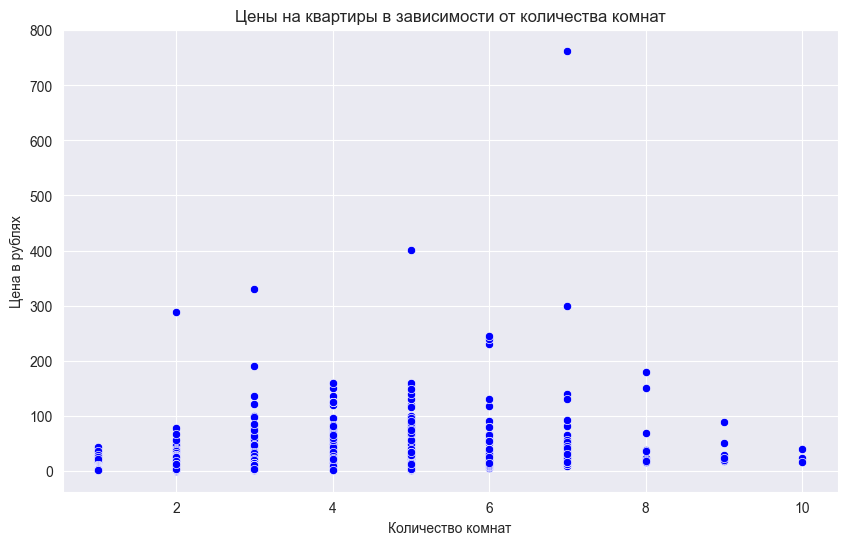

In [70]:
df_pure['Цена в миллионах'] = df_pure['Цена'] / 1_000_000
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Количество комнат', y='Цена в миллионах', data=df_pure, color='blue')
plt.title('Цены на квартиры в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена в рублях')
plt.grid(True)
plt.show()

Вывели более наглядные графики, преобразовав вывод цены на вывод в миллионах рублей. И сделаем небольшие выводы, прежде чем переходить к корреляционной матрице:
- Есть самый большой выброс - в районе 700+ миллионов
- Также три выброса отмечаем в пределе 300 - 400 миллионов
- Далее - есть один выброс в двухкомнатных квартирах - цена почти 300 миллионов рублей, а также в шестикомнатных - есть группа гораздо выше среднего по своей 6-комнатным - более 220 миллионов рублей
- В большой выборке свыше 6 комнат квартир оказалось предостаточно - как 7-8-9-10 комнатных, представленных нескольким количеством предложений
- Посчитаем, сколько же у нас предложений в каждой группе по количеству комнат

In [71]:
filtered_rooms_6plus = df_pure[df_pure['Количество комнат'] >= 6]
rooms_count = filtered_rooms_6plus['Количество комнат'].value_counts().reset_index()


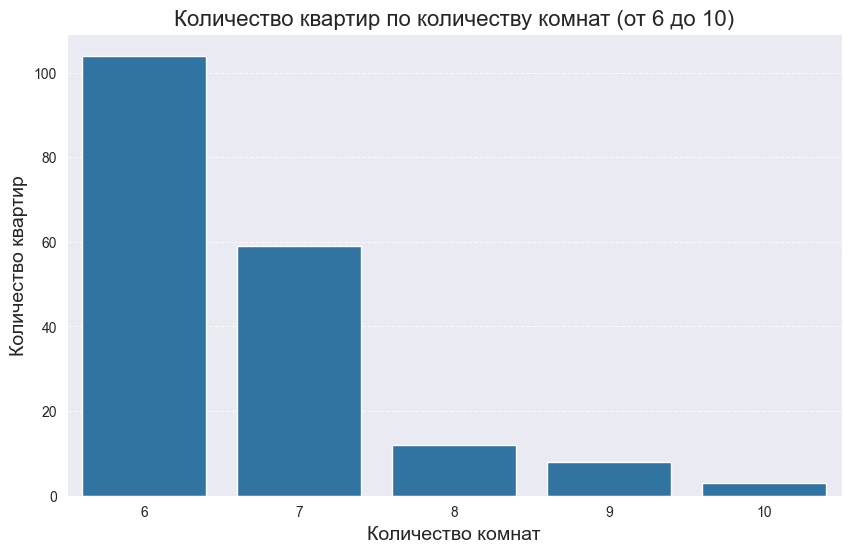

In [72]:
rooms_count.columns = ['Количество комнат', 'count']
plt.figure(figsize=(10, 6))
sns.barplot(data=rooms_count, x='Количество комнат', y='count')
plt.title('Количество квартир по количеству комнат (от 6 до 10)', fontsize=16)
plt.xlabel('Количество комнат', fontsize=14)
plt.ylabel('Количество квартир', fontsize=14)
plt.xticks(rotation=0)  

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Смотрим, что у нас:
- 6-комнатные - более 100 предложений
- 7-комнатные - около 60 предложений
- 8-комнатные - более 15 предложений
- 9-комнатные - чуть больше 10 предложений
- 10-комнатные - меньше 5 - но мы видели на графике - их 3
- Выведем же общее количество квартир в этой группе 6+


In [73]:
filtered_rooms_5minus = df_pure[df_pure['Количество комнат'] <= 5]
rooms_count_5 = filtered_rooms_5minus['Количество комнат'].value_counts().reset_index()

In [74]:
print(f"Квартир, в которых 6 и более комнат - {len(filtered_rooms_6plus)} предложений")
print(f"Квартир, в которых 5 и менее комнат - {len(filtered_rooms_5minus)} предложений ")
print(f"Количество в процентном соотношении 6+ к 5- = {len(filtered_rooms_6plus) / len(filtered_rooms_5minus):.1%}")
print(f"Количество в процентном соотношении 6+ к общей выборке = {len(filtered_rooms_6plus) / len(filtered_rooms_5minus + filtered_rooms_6plus):.1%}")
print(f"Количество в процентном соотношении 5- к общей выборке = {len(filtered_rooms_5minus) / len(filtered_rooms_5minus + filtered_rooms_6plus):.1%}")

Квартир, в которых 6 и более комнат - 186 предложений
Квартир, в которых 5 и менее комнат - 23201 предложений 
Количество в процентном соотношении 6+ к 5- = 0.8%
Количество в процентном соотношении 6+ к общей выборке = 0.8%
Количество в процентном соотношении 5- к общей выборке = 99.2%


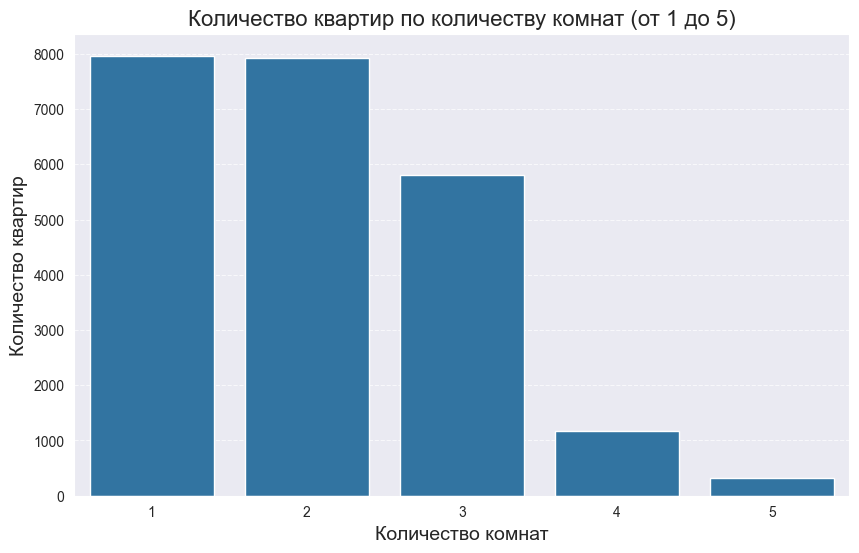

In [75]:
rooms_count_5.columns = ['Количество комнат', 'count']
plt.figure(figsize=(10, 6))
sns.barplot(data=rooms_count_5, x='Количество комнат', y='count')
plt.title('Количество квартир по количеству комнат (от 1 до 5)', fontsize=16)
plt.xlabel('Количество комнат', fontsize=14)
plt.ylabel('Количество квартир', fontsize=14)
plt.xticks(rotation=0)  

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 Посмотрев график с выводом второй - более многочисленной группы - мы видим, что:
- примерно равное количество, но с доминированием однокомнатных - в районе 8000 у нас однушки и двушки
- трёхкомнатных предложений около 6000 и это третья группа по значимости на графике
- четырёхкомнатных квартир более 1000
- пятикомнатных - около 300 предложений

In [76]:
print(df_pure["Количество комнат"].value_counts())

Количество комнат
1     7967
2     7921
3     5808
4     1179
5      326
6      104
7       59
8       12
9        8
10       3
Name: count, dtype: int64


Мы видим, что точные цифры следующие:
- 1-комнатные - 7967
- 2-комнатные - 7921
- 3-комнатные - 5808
- 4-комнатные - 1179
- 5-комнатные - 326
- 6-комнатные - 104
- 7-комнатные - 59
- 8-комнатные - 12
- 9-комнатные - 8
- 10-комнатные - 3 

In [77]:
all_rooms = len(filtered_rooms_5minus + filtered_rooms_6plus)

In [78]:
def calculate_room_percentage(df, room_column):
    room_counts = room_column.value_counts().reset_index()
    room_counts.columns = ['Количество комнат', 'Количество квартир']
    room_counts['Проценты'] = (room_counts['Количество квартир'] / all_rooms) * 100

    return room_counts

In [79]:
result_rooms = calculate_room_percentage(df_pure, df_pure['Количество комнат'])

In [80]:
result_rooms

,Количество комнат,Количество квартир,Проценты
0,1,7967,34.07
1,2,7921,33.87
2,3,5808,24.83
3,4,1179,5.04
4,5,326,1.39
5,6,104,0.44
6,7,59,0.25
7,8,12,0.05
8,9,8,0.03
9,10,3,0.01


In [81]:
sum_value_rooms = result_rooms["Проценты"][1]+result_rooms["Проценты"][0]+result_rooms["Проценты"][2]
print(f"Больше всего в нашей выборке предложений с одно-двух и трёхкомнатными квартирами: {result_rooms["Проценты"][0]/100:.1%} - однокомнатные плюс  {result_rooms["Проценты"][1]/100:.1%} - двухкомнатные плюс {result_rooms["Проценты"][2]/100:.1%} трёхкомнатные - получаем  {sum_value_rooms/100:.1%}")

Больше всего в нашей выборке предложений с одно-двух и трёхкомнатными квартирами: 34.1% - однокомнатные плюс  33.9% - двухкомнатные плюс 24.8% трёхкомнатные - получаем  92.8%


В результате видим, что самое большое количество в нашей выборке одно-двух-трёхкомнатных и это 92.8% всей выборки

Кажется, что чего-то не хватает для объективности - давайте сделаем новую колонку с показателем цены за квадратный метр - это точно нам поможет в дальнейшем при доказательстве гипотез. Ведь мы предполагаем, что цена за квадратный метр будет разниться от тех немаловажных факторов, что нами были исследованы и на маленьких выборках, и на большой. Также это будет плюсом для вывода корреляционной матрицы

In [82]:
df_pure["Цена за квадратный метр"] = df_pure["Цена"] / df_pure["Общая площадь"]

Когда добавили цену за квадратный метр, внезапно поняли что есть аномалии когда общая площадь намного больше жилой площади. Как можно покупать квартиру с 159 квадратными метрами и только 30 метрами жилой, при том что нет балкона. Поэтому попробуем вывести те предложения, которые для нас являются аномальными. 
Ведь жилая площадь — общая площадь всех жилых комнат. А общая площадь квартиры включает все помещения, в том числе подсобные, не включаются только балконы, террасы и лоджии. Есть еще один параметр — площадь квартиры. В него входят все помещения, которыми может использовать собственник. То есть получается что аномалией будет считаться как минимум превышение в полтора раза общей площадью жилой

In [83]:
df_cor15 =  df_pure[df_pure["Общая площадь"]/df_pure["Жилая площадь"] >= 1.5]

In [84]:
df_cor20 = df_pure[df_pure["Общая площадь"]/df_pure["Жилая площадь"] >= 2]

In [85]:
cor20 = df_pure[df_pure["Общая площадь"]/df_pure["Жилая площадь"] >= 2]

In [86]:
cor15 = df_pure[df_pure["Общая площадь"]/df_pure["Жилая площадь"] >= 1.5]

In [87]:
df_pure = df_pure.drop(cor20.index)

In [88]:
df_pure = df_pure.drop(cor15.index)

KeyError: '[0, 1, 3, 4, 5, 6, 7, 8, 14, 17, 24, 28, 34, 38, 40, 42, 48, 51, 53, 54, 56, 57, 67, 75, 78, 81, 82, 83, 93, 100, 101, 103, 105, 110, 111, 114, 116, 121, 123, 134, 135, 136, 137, 140, 148, 156, 160, 161, 165, 166, 167, 176, 185, 186, 188, 192, 195, 196, 198, 199, 203, 208, 210, 218, 219, 228, 230, 232, 239, 245, 248, 251, 252, 254, 255, 259, 261, 263, 265, 266, 272, 274, 275, 276, 281, 288, 294, 295, 307, 323, 324, 331, 338, 343, 352, 357, 363, 367, 369, 370, 371, 372, 374, 375, 376, 379, 380, 384, 385, 387, 388, 391, 394, 397, 406, 410, 413, 414, 419, 420, 421, 423, 427, 432, 437, 438, 441, 442, 443, 447, 451, 454, 460, 465, 466, 468, 472, 477, 482, 484, 492, 493, 494, 499, 511, 523, 525, 530, 532, 538, 550, 553, 561, 563, 567, 568, 569, 570, 572, 573, 574, 576, 579, 581, 585, 586, 595, 597, 598, 599, 609, 612, 614, 615, 622, 623, 629, 639, 640, 643, 644, 656, 665, 666, 667, 668, 672, 676, 679, 680, 685, 689, 691, 692, 698, 699, 701, 707, 709, 710, 711, 713, 714, 723, 728, 

Итак, мы получаем - в одном случае при показателе - больше или равно 1.5 - то есть что общая площадь может превышать жилую в 1.5 раза и более - таких значений 19.379. А в случае, когда мы ставим показатель 2 - что общая площадь может превышать жилую в два и более раза - получаем 6661 строку с предложениями.
Так как это довольно большая часть нашей выборки, то перенесём эти данные в два новых датафрейма, а с нашего основного их удалим, и проанализируем отдельно полученные результаты.

В таком случае получаем выборку в 4008 записей, а также две других - которые мы будем изучать каждую отдельно, чтобы понять насколько такие аномалии нам помешают сделать выводы или не помешают вовсе.


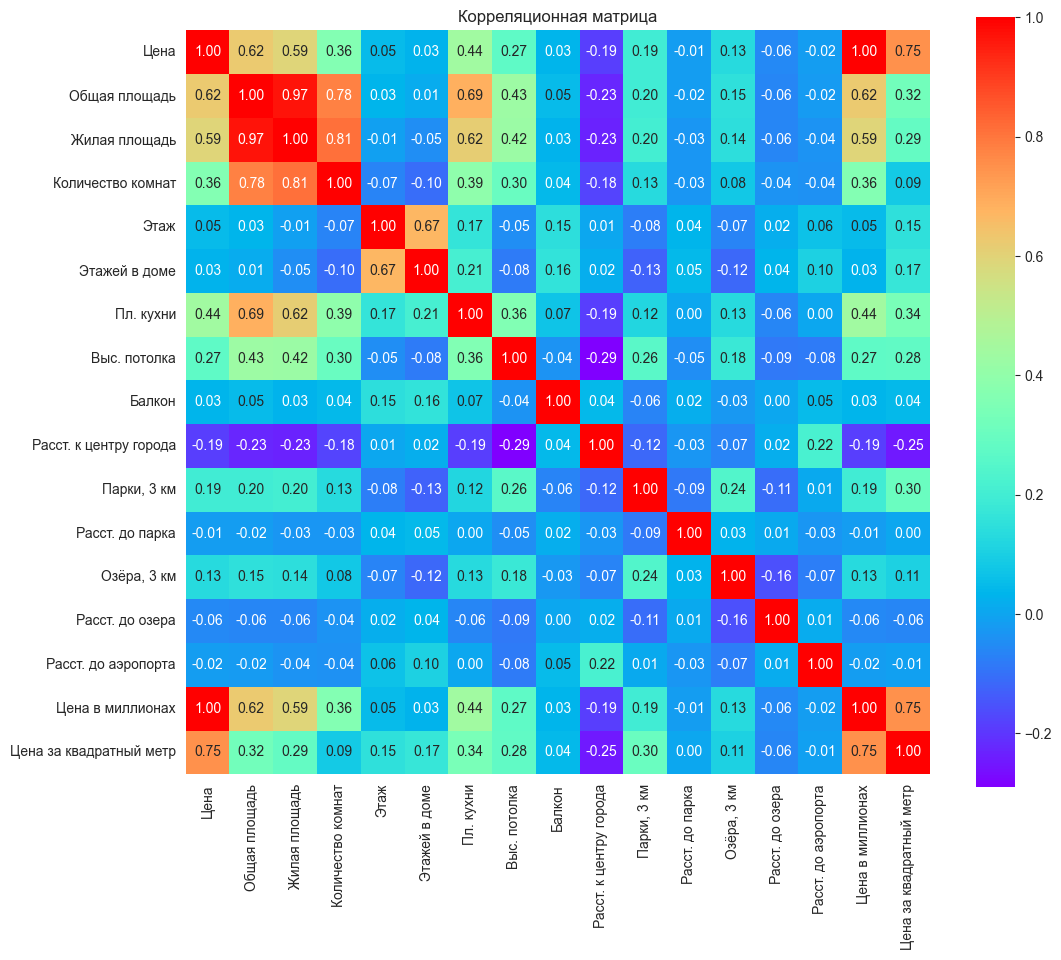

In [89]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_pure.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='rainbow', square=True)
plt.title('Корреляционная матрица')
plt.show()

Итак, ранее мы уже проводили анализ на меньших выборках, и получили результаты. Посмотрим так ли всё то, что мы открыли ранее для выборки из 4008 строк - значений, над которой мы изрядно поработали, для чистоты эксперимента:
- Первое, что бросается в глаза - это то, что жилая площадь почти в равной степени влияет на цену как общая - но жилая в данном случае даже больше - и это нам кажется вполне логичным.
- Площадь же кухни тоже имеет важное значение и напрямую зависит от общей площади и жилой.
- Следующим фактором по значимости является количество комнат - ну да, все хотят семью, больше пространства, и редко встретишь квартиру 1-2-комнатную с огромной жилой площадью. Хотя эту гипотезу мы тоже потом докажем или опровергнем - но выведем график зависимости площади на количество комнат
- Итак, далее - высота потолка напрямую влияет на цену, а также наличие парков - их количества в радиусе 3 км - свежий воздух, свобода, дети, семья - какие-то такие ассоциации от данной корреляции
- Ну и практически таким же фактором как наличие парков, является фактор расстояния до центра города
- Количество же озёр в два раза меньше влияет на цену, чем количество парков на тот же радиус
- Уже не таким значимым, но всё ещё влияющим на цену - являются факторы расстояния до парка и до озера. Оно и понятно, практически у большинства машины - и этот фактор скорее всего больше значим дял пожилых людей, а может ещё для тех кто любит бегать в парке или постоянно посещать озёра - например рыбаки. Но, как мы помним что мода расстояния до озёр у нас в районе 500 метров - а значит озёр и парков достаточно много, и это скорее всего влияет, но не сильно на цену
- Осталось ещё два фактора, которые по значению равны, хотя и обозначают разные корреляции - это этажность дома и расстояние до аэропорта - и здесь как раз то самое - что много вопросов и по поводу вкусовщины и по поводу удобно ли жить в высоком доме и жить близко к аэропорту - это скорее будет минусом для большинства, чем плюсом.
- И последние два фактора которые никак не влияют на цену квартиры - являются наличие балкона и этаж на каком жить - что странно, так как обычно балкон является важным преимуществом, так как не входит в общую площадь жилой, но универсален в своём использовании, а этаж люди обычно стараются брать средний, чтобы было не тяжело подниматься и не долго спускаться. А так как у нас в выборке в основном квартиры из 5-этажных домов (выведем позже), то предполагаем, что не везде в этих домах есть лифты. 

А теперь хочется посмотреть из чего напрямую складывается цена за квадратный метр и здесь по матрице видно, что из всего, но в разнйо степени:
- Коэффициент 0.30+ - площадь кухни, парки в радиусе 3 км и жилая площадь
- Коэффициент 0.20+ - общая площадь, высота потолка, расстояние к центру города (здесь чем оно меньше, тем лучше)
- Коэффициент 0.10+ - озёра в радиусе 3 км, этажность дома, этаж (ну вот, наконец-то мы увидели что всё-таки он значим)
- Коэффициент 0.5+ - расстояние до озера, количество комнат
- Коэффициент 0.5- - расстояние до аэропорта, расстояние до парка, балкон

Посмотрим теперь две аномальные матрицы, как нам кажется и сравним полученные данные в каждой

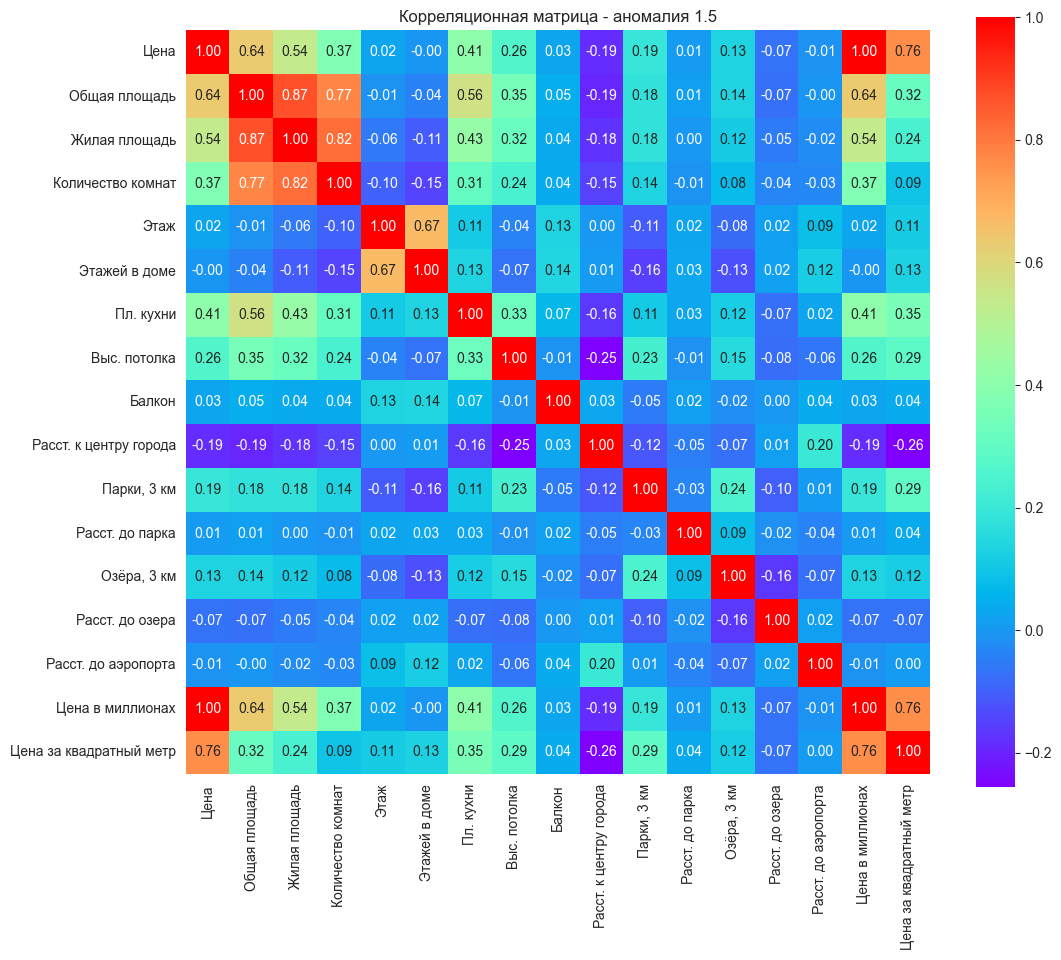

In [91]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_cor15.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='rainbow', square=True)
plt.title('Корреляционная матрица - аномалия 1.5')
plt.show()

Как видим в Аномалии 1.5 у нас некоторые значения совершенно не отображаются - как расстояние до аэропорта в цене за квадратный метр, также значения жилой площади и общей площади занижены, а также зависимости между ними совершенно в других пропорциях - ну это и понятно.
В целом же все факторы, что были ранее нами озвучены здесь также коррелируют к цене, хотя и значения различаются от приведённых выше с более чистой выборки.

А теперь посомтрми Аномалию 2

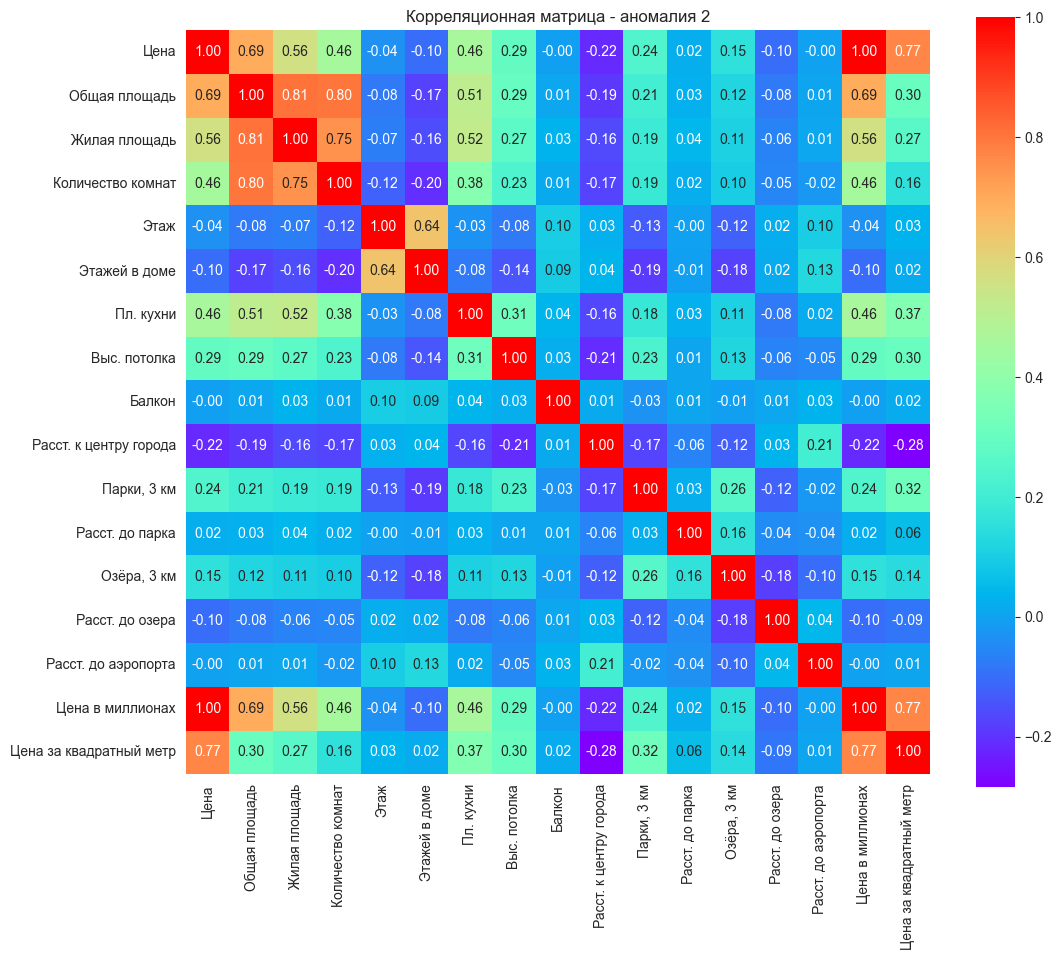

In [92]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_cor20.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='rainbow', square=True)
plt.title('Корреляционная матрица - аномалия 2')
plt.show()

Здесь такая же примерно картина как, и в предыдущем случае, только ещё больше получает зависимость от общей - жилая площадь. Наблюдаем те же самые важные факторы, как размер кухни, высота потолков, количество комнат. Правда, цифры несколько отличаются от чистой выборки.

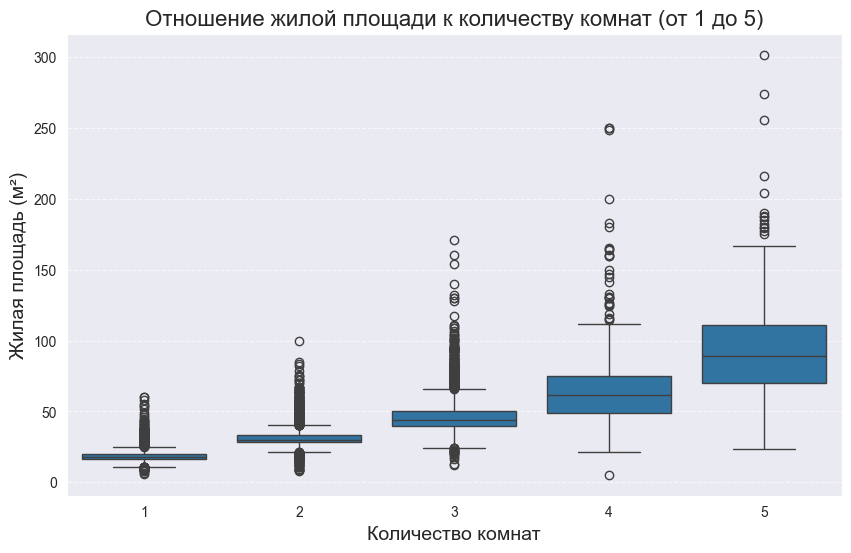

In [93]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_rooms_5minus, x='Количество комнат', y='Жилая площадь')
plt.title('Отношение жилой площади к количеству комнат (от 1 до 5)', fontsize=16)
plt.xlabel('Количество комнат', fontsize=14)
plt.ylabel('Жилая площадь (м²)', fontsize=14)
plt.xticks(rotation=0)  

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Как видим, что однокомнатные квартиры не превышают по площади 60 метров квадратных, а двухкомнатные растут до 80 по площади, а 100 - это скорее выброс, чем закономерность. Трёхкомнатные с более широким диапазоном жилой площади - и есть квартиры свыше 150 метров квадратных, четырёхкомнатные до 200, а пятикомнатные бывают и свыше 250, и одно предложение свыше 300 метров

In [94]:
floors_house = df_pure["Этажей в доме"].value_counts().reset_index()

In [95]:
floors_house

,Этажей в доме,count
0,5,5029
1,9,3172
2,12,1023
3,4,923
4,16,755
5,10,682
6,6,667
7,3,524
8,25,497
9,7,425


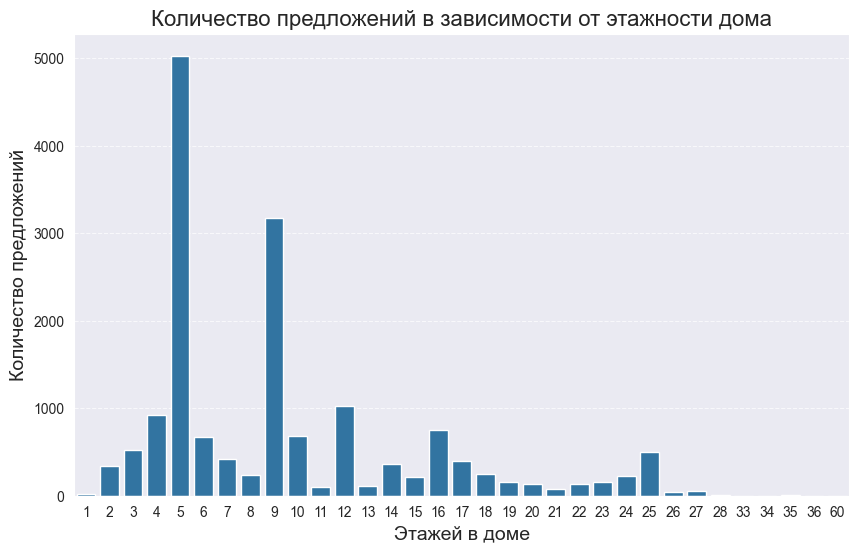

In [96]:
plt.figure(figsize=(10, 6))
sns.barplot(data=floors_house, x='Этажей в доме', y='count')
plt.title('Количество предложений в зависимости от этажности дома', fontsize=16)
plt.xlabel('Этажей в доме', fontsize=14)
plt.ylabel('Количество предложений', fontsize=14)
plt.xticks(rotation=0)  

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Итак, очередная наша гипотеза подтвердилась - у нас 1682 предложения из 5-этажных домов, что почти половина всей выборки "чистой", что мы рассматриваем. 
- Следующим по количеству предложений идут девятиэтажные дома - 754 предложения
- Четырёхэтажные занимают третье место в нашем списке предложений со значением 293
- Более 100 предложений у 6-этажек, двухэтажек, трёх, семи и двенадцати, но лидер 6-этажки - 173 предложения
- Внизу нашего списка 1 предложение с квартирой из 35-этажного дома
- А чуть выше - на предпоследнем месте - 1этажный дом - 5 предложений (как бы странно это не звучало)

In [97]:
df_pure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16726 entries, 2 to 23696
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Цена                     16726 non-null  float64
 1   Общая площадь            16726 non-null  float16
 2   Жилая площадь            16726 non-null  float16
 3   Количество комнат        16726 non-null  int16  
 4   Этаж                     16726 non-null  int16  
 5   Этажей в доме            16726 non-null  int16  
 6   Пл. кухни                16726 non-null  float16
 7   Выс. потолка             16726 non-null  float16
 8   Балкон                   16726 non-null  int16  
 9   Расст. к центру города   16726 non-null  float16
 10  Парки, 3 км              16726 non-null  int16  
 11  Расст. до парка          16726 non-null  float16
 12  Озёра, 3 км              16726 non-null  int16  
 13  Расст. до озера          16726 non-null  float16
 14  Расст. до аэропорта      16

Итак, давайте резюмируем, чем же мы тут занимались:
1. В начале пути в задании нигде не было сказано, как именно очищать данные, и мы начали с малой выборки, и постепенно строя новые гипотезы, доказывали их, увеличивая выборку раз за разом
2. Нами был проведён анализ довольно грязного датафрейма, мы сделали разведочный анализ, и иногда его повторяли, для того, чтобы не пойти по ложному пути
3. Для подкрепления наших доводов мы строили графики, и выводили результаты, пусть не такие красивые как хотелось, но благо у нас есть плагины в EDA, чтобы графики строились самостоятельно. Именно такие графики мы планируем использовать в презентации - они нагляднее и интересней. Хотя, построенные нами вполне себе читаемы.
4. В процессе анализа мы постоянно находили новые аномалии, потому что нам было интересно получить на выходе чистые данные, чтобы эксперимент не был омрачён неточностями. Поэтому мы нашли слишком высокие потолки, полностью дублирующие строки, аномалии с корреляцией общей площади и жилой и тд.
5. Мы привели наш датафрейм к более быстрому виду, чтобы он запускался и выполнялся быстрее - 16битные - инты и флоаты, а также некоторые флоаты заранее перевели в инты, чтобы не было путаницы, ведь при очистке данных "nan" мы в третьей выборке решили заменять на медианные значения. Сейчас, нащ чистый датафрейм содержит 4008 строк и весит 234.8 К. Правда, в процессе решили отказаться от столбцов с планировкой квартир, так как очень грязные данные с огромным числом пропусков, и не было заказчика у которого спросить как с ними поступить. Исходя из того, что всего было три планировки - общий план, апартаменты и студия - но при этом в апартаментах было либо False, либо Nan в большинстве случаев - мы отказались от параметров планировок, по приведённым выше соображениям.
6. Также мы русифицировали название каждого столбца, чтобы было удобнее читать выборку, и разложили выборку как нам казалось правильным, расположив данные столбцов в определённой сортировке по отношению друг ко другу
7. С помощью графиков, вывода матрицы корреляционной мы пришли к выводу, что главным образом на цену влияют факторы, кроме количества комнат, общей и жилой площади, площадь кухни, высота потолков, наличие парков в радиусе 3000 м, а также рассстояние до центра города (чем меньше тем лучше). Менее значимыми факторами для роста цены являются - наличие озёр в радиусе 3000 м, а также расстояние до озера(водоёма), этаж и расстояние до аэропорта достаточно спорные - но показывают корреляцию к цене 0.05, что является чуть больше половины фактора наличие озёр в радиусе 3000 м
8. Из чего же состоит цена за квадратный метр, чтобы модель прогнозирования стоимости квартир нами была получена:
- Коэффициент 0.30+ - площадь кухни, парки в радиусе 3 км и жилая площадь
- Коэффициент 0.20+ - общая площадь, высота потолка, расстояние к центру города (здесь чем оно меньше, тем лучше)
- Коэффициент 0.10+ - озёра в радиусе 3 км, этажность дома, этаж (ну вот, наконец-то мы увидели что всё-таки он значим)
- Коэффициент 0.5+ - расстояние до озера, количество комнат
- Коэффициент 0.5- - расстояние до аэропорта, расстояние до парка, балкон
9. Получается, что стоимость квартиры за квадратный метр будет в первую очередь зависеть от площади кухни, и парков в радиусе 3 км, а также жилой площади, затем от общей площади, высоты потолков, а также приближённости к центру города, далее - от озёр в радиусе 3 км, этажность дома и этажа, на котором находится квартира, и также нужно учитывать расстояние до озера, количество комнат в квартире, а вот расстояние до парка, балкон, и расстояние до аэропорта могут даже снизить цену, либо незначительно на неё повлиять.